# Cell type-wise SDAE Biomarker Identification for AKI / CKD / Ref

**Dataset:** `GSE183276_scCv3_with_metadata.h5ad`  
**Condition column:** `condition.l1` → `AKI`, `CKD`, `Ref`  
**Cell type column:** `subclass.l1`  

এই notebook-এর কাজ:

1. শুধু selected cell types নেয়: `PT, TAL, IMM, EC, IC, PC, CNT, DCT`.
2. প্রতিটি cell type আলাদা করে analysis করে।
3. প্রতিটি cell type-এর ভিতরে `AKI = CKD = Ref` balanced cell নেয়।
4. Ref count নেওয়া সম্ভব হলে প্রতি condition-এ Ref count নেয়। যদি কোনো condition Ref-এর চেয়ে কম থাকে, তাহলে smallest condition count নেয়, কারণ replacement ছাড়া perfect balance করার একমাত্র safe way এটা।
5. প্রতি cell type-এর জন্য variance-based top **3000 HVG** নেয়।
6. Train / validation / test split করে, split-এর ভিতরেও 3 condition balanced রাখে।
7. Supervised Denoising Autoencoder train করে।
8. Gradient × Input importance + expression direction দিয়ে AKI / CKD / Ref biomarker genes বের করে।

Output folder: `results_celltype_sdae_3000hvg_biomarkers/`

## Cell 1 — Required packages

প্রথমবার run করলে নিচের install line uncomment করতে পারো। Already installed থাকলে দরকার নেই।

In [10]:
# Uncomment if needed
# !pip install scanpy anndata numpy pandas scipy scikit-learn matplotlib torch openpyxl

## Cell 2 — Import libraries and setup seed

কেন করা হচ্ছে:
- `scanpy/anndata`: `.h5ad` read করার জন্য।
- `torch`: SDAE model train করার জন্য।
- `sklearn`: train/val/test split, scaling, metric calculation.
- fixed seed দিলে result reproducible হয়।

In [11]:
import os
import gc
import random
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
sc.settings.verbosity = 2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU available থাকলে FORCE_CPU=False করো। CPU safe রাখার জন্য default True.
FORCE_CPU = True
if FORCE_CPU:
    DEVICE = "cpu"
else:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)

Device: cpu


## Cell 3 — Dataset path and output folders

`DATA_PATH` তোমার local dataset location অনুযায়ী ঠিক করো। Notebook কয়েকটা common fallback path check করবে।

In [12]:
DATA_PATH = "data/GSE183276_scCv3_with_metadata.h5ad"

possible_paths = [
    Path(DATA_PATH),
    Path("GSE183276_scCv3_with_metadata.h5ad"),
    Path("data/GSE183276_scCv3_with_metadata.h5ad"),
    Path.cwd() / DATA_PATH,
    Path.cwd().parent / DATA_PATH,
]

DATA_FILE = None
for p in possible_paths:
    if p.exists():
        DATA_FILE = p.resolve()
        break

if DATA_FILE is None:
    raise FileNotFoundError(
        "Dataset not found. Put GSE183276_scCv3_with_metadata.h5ad in current folder or data/ folder, "
        "or update DATA_PATH."
    )

PROJECT_DIR = DATA_FILE.parent.parent if DATA_FILE.parent.name == "data" else DATA_FILE.parent
OUTPUT_DIR = PROJECT_DIR / "results_celltype_sdae_3000hvg_biomarkers"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
for d in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_FILE)
print("Output directory:", OUTPUT_DIR)

Dataset: /home/nazmul/Research/Celltype SDAE/data/GSE183276_scCv3_with_metadata.h5ad
Output directory: /home/nazmul/Research/Celltype SDAE/results_celltype_sdae_3000hvg_biomarkers


## Cell 4 — Analysis parameters

এখানে main settings রাখা হয়েছে।

- `TARGET_CELL_TYPES`: তুমি যে 8 cell type দেখিয়েছো সেগুলো।
- `N_TOP_HVG=3000`: প্রতিটি cell type-এর balanced data থেকে top 3000 variable genes।
- `BALANCE_BY_REF_WHEN_POSSIBLE=True`: Ref count যদি AKI/CKD থেকে বেশি না হয়, তাহলে প্রতি condition-এ Ref count নেওয়া হবে।
- যদি Ref count কোনো condition-এর চেয়ে বেশি হয়, notebook automatically smallest condition count নেবে, যাতে replacement ছাড়া clean balance হয়।

In [13]:
CONDITION_COL = "condition.l1"
CELLTYPE_COL = "subclass.l1"

TARGET_CLASSES = ["AKI", "CKD", "Ref"]
TARGET_CELL_TYPES = ["PT", "TAL", "IMM", "EC", "IC", "PC", "CNT", "DCT"]

N_TOP_HVG = 3000
TEST_SIZE = 0.20
VAL_SIZE_FROM_TRAIN = 0.15

BATCH_SIZE = 128
EPOCHS = 30
PATIENCE = 7
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

NOISE_PROB = 0.20
LATENT_DIM = 32
HIDDEN_DIMS = (512, 128)
RECON_LOSS_WEIGHT = 1.0
CLASS_LOSS_WEIGHT = 1.5

BALANCE_BY_REF_WHEN_POSSIBLE = True
ALLOW_REPLACEMENT_IF_REF_LARGER = False  # True করলে Ref count force করতে oversampling হবে; research-এর জন্য False better.

TOP_N_GENES_PER_CLASS = 200
IMPORTANCE_MAX_CELLS_PER_CLASS = 400

print("Target classes:", TARGET_CLASSES)
print("Target cell types:", TARGET_CELL_TYPES)
print("N_TOP_HVG:", N_TOP_HVG)

Target classes: ['AKI', 'CKD', 'Ref']
Target cell types: ['PT', 'TAL', 'IMM', 'EC', 'IC', 'PC', 'CNT', 'DCT']
N_TOP_HVG: 3000


## Cell 5 — Load dataset and check columns

Dataset load করে condition ও cell-type columns আছে কিনা check করা হচ্ছে।

In [14]:
adata = sc.read_h5ad(DATA_FILE)
print(adata)
print("Shape cells x genes:", adata.shape)
print("X type:", type(adata.X))

missing_cols = [c for c in [CONDITION_COL, CELLTYPE_COL] if c not in adata.obs.columns]
if missing_cols:
    raise KeyError(f"Missing columns in adata.obs: {missing_cols}")

display(adata.obs[[CONDITION_COL, CELLTYPE_COL]].head())

AnnData object with n_obs × n_vars = 109741 × 37080
    obs: 'sample', 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module'
    var: 'gene_symbol'
    la

,condition.l1,subclass.l1
AKI3010018_AAACCCACAGGGATAC-1,AKI,PT
AKI3010018_AAACCCATCTGATGGT-1,AKI,EC
AKI3010018_AAACCCATCTGCTTTA-1,AKI,PT
AKI3010018_AAACGAATCTCCAATT-1,AKI,IMM
AKI3010018_AAACGAATCTTTCCAA-1,AKI,TAL


## Cell 6 — Dataset summary

এখানে original condition count এবং cell type count দেখা হবে।

In [15]:
print("Condition counts:")
display(adata.obs[CONDITION_COL].astype(str).value_counts().rename("count").to_frame())

print("Cell type counts:")
display(adata.obs[CELLTYPE_COL].astype(str).value_counts().rename("count").to_frame())

Condition counts:


,count
condition.l1,
CKD,52314
AKI,35777
Ref,21650


Cell type counts:


,count
subclass.l1,
PT,25373
TAL,23894
IMM,17176
EC,8550
IC,8334
PC,7483
CNT,6459
DCT,5324
VSM/P,3011


## Cell 7 — Selected cell-type condition table

প্রতিটি selected cell type-এর ভিতরে AKI/CKD/Ref কত cell আছে তা দেখা হবে। এরপর notebook decide করবে প্রতি condition কত cell নেওয়া যাবে।

In [16]:
obs_tmp = adata.obs[[CONDITION_COL, CELLTYPE_COL]].copy()
obs_tmp[CONDITION_COL] = obs_tmp[CONDITION_COL].astype(str)
obs_tmp[CELLTYPE_COL] = obs_tmp[CELLTYPE_COL].astype(str)

rows = []
for ct in TARGET_CELL_TYPES:
    sub = obs_tmp[obs_tmp[CELLTYPE_COL] == ct]
    counts = sub[CONDITION_COL].value_counts().to_dict()
    row = {
        "cell_type": ct,
        "total_cells": int(len(sub)),
        "condition_count__AKI": int(counts.get("AKI", 0)),
        "condition_count__CKD": int(counts.get("CKD", 0)),
        "condition_count__Ref": int(counts.get("Ref", 0)),
    }
    vals = [row[f"condition_count__{c}"] for c in TARGET_CLASSES]
    if all(v > 0 for v in vals):
        ref_n = row["condition_count__Ref"]
        min_n = min(vals)
        if BALANCE_BY_REF_WHEN_POSSIBLE and all(v >= ref_n for v in vals):
            selected_n = ref_n
            reason = "Ref count used"
        elif ALLOW_REPLACEMENT_IF_REF_LARGER and ref_n > 0:
            selected_n = ref_n
            reason = "Ref count forced with replacement"
        else:
            selected_n = min_n
            reason = "minimum condition count used"
        row["status"] = "valid"
        row["selected_cells_per_condition"] = int(selected_n)
        row["balanced_total_cells"] = int(selected_n * len(TARGET_CLASSES))
        row["balance_reason"] = reason
    else:
        row["status"] = "invalid_missing_condition"
        row["selected_cells_per_condition"] = 0
        row["balanced_total_cells"] = 0
        row["balance_reason"] = "one or more condition missing"
    rows.append(row)

celltype_summary = pd.DataFrame(rows)
celltype_summary.to_csv(TABLE_DIR / "selected_celltype_condition_balance_summary.csv", index=False)
display(celltype_summary)

,cell_type,total_cells,condition_count__AKI,condition_count__CKD,condition_count__Ref,status,selected_cells_per_condition,balanced_total_cells,balance_reason
0,PT,25373,8304,11886,5183,valid,5183,15549,Ref count used
1,TAL,23894,8930,11319,3645,valid,3645,10935,Ref count used
2,IMM,17176,8819,6884,1473,valid,1473,4419,Ref count used
3,EC,8550,1915,3905,2730,valid,1915,5745,minimum condition count used
4,IC,8334,1110,5023,2201,valid,1110,3330,minimum condition count used
5,PC,7483,2025,4632,826,valid,826,2478,Ref count used
6,CNT,6459,1583,2705,2171,valid,1583,4749,minimum condition count used
7,DCT,5324,824,2694,1806,valid,824,2472,minimum condition count used


## Cell 8 — Helper functions

এই cell-এ reusable functions রাখা হয়েছে:

- sparse/dense matrix variance calculation
- balanced sampling
- train/val/test split
- dataset/dataloader
- metric calculation
- plotting

In [17]:
def to_dense_float32(X):
    if sp.issparse(X):
        X = X.toarray()
    return np.asarray(X, dtype=np.float32)


def sparse_or_dense_variance(X):
    if sp.issparse(X):
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean_sq = np.asarray(X.multiply(X).mean(axis=0)).ravel()
        var = mean_sq - mean ** 2
    else:
        var = np.var(np.asarray(X), axis=0)
    return np.asarray(var).ravel()


def make_safe_name(x):
    return str(x).replace("/", "_").replace(" ", "_")


def choose_n_per_condition(counts_dict):
    vals = [int(counts_dict.get(c, 0)) for c in TARGET_CLASSES]
    if not all(v > 0 for v in vals):
        return 0, "invalid_missing_condition"
    ref_n = int(counts_dict.get("Ref", 0))
    min_n = int(min(vals))
    if BALANCE_BY_REF_WHEN_POSSIBLE and all(v >= ref_n for v in vals):
        return ref_n, "Ref count used"
    if ALLOW_REPLACEMENT_IF_REF_LARGER and ref_n > 0:
        return ref_n, "Ref count forced with replacement"
    return min_n, "minimum condition count used"


def balanced_indices_for_celltype(adata_obj, cell_type, seed=42):
    rng = np.random.default_rng(seed)
    obs = adata_obj.obs
    ct_mask = obs[CELLTYPE_COL].astype(str).values == str(cell_type)
    cond_values = obs[CONDITION_COL].astype(str).values
    counts = {c: int(np.sum(ct_mask & (cond_values == c))) for c in TARGET_CLASSES}
    n_per_cond, reason = choose_n_per_condition(counts)
    if n_per_cond <= 0:
        raise ValueError(f"Cell type {cell_type} is not valid for 3-class balance: {counts}")

    selected = []
    sampled_counts = {}
    for cls in TARGET_CLASSES:
        idx = np.where(ct_mask & (cond_values == cls))[0]
        replace = n_per_cond > len(idx)
        chosen = rng.choice(idx, size=n_per_cond, replace=replace)
        selected.extend(chosen.tolist())
        sampled_counts[cls] = int(len(chosen))
    selected = np.array(selected, dtype=int)
    rng.shuffle(selected)
    return selected, counts, sampled_counts, reason


def make_stratified_split(y, seed=42):
    all_idx = np.arange(len(y))
    train_val_idx, test_idx = train_test_split(
        all_idx,
        test_size=TEST_SIZE,
        random_state=seed,
        stratify=y,
    )
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=VAL_SIZE_FROM_TRAIN,
        random_state=seed,
        stratify=y[train_val_idx],
    )
    return train_idx, val_idx, test_idx


class ExpressionDataset(Dataset):
    def __init__(self, X, y, indices):
        self.X = torch.tensor(X[indices], dtype=torch.float32)
        self.y = torch.tensor(y[indices], dtype=torch.long)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loaders(X, y, train_idx, val_idx, test_idx):
    train_ds = ExpressionDataset(X, y, train_idx)
    val_ds = ExpressionDataset(X, y, val_idx)
    test_ds = ExpressionDataset(X, y, test_idx)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, test_loader


def save_confusion_matrix_plot(cm_df, out_png, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm_df.values, interpolation="nearest")
    plt.title(title)
    plt.xticks(np.arange(len(cm_df.columns)), cm_df.columns, rotation=45, ha="right")
    plt.yticks(np.arange(len(cm_df.index)), cm_df.index)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            plt.text(j, i, str(cm_df.iloc[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()

## Cell 9 — SDAE model

Model architecture:

Input gene expression → Encoder → latent vector → Decoder reconstructs expression  
Latent vector → Classifier predicts AKI / CKD / Ref

Loss:

\[
Loss = \lambda_{recon} \cdot MSE(X, \hat X) + \lambda_{cls} \cdot CrossEntropy(y, \hat y)
\]

Denoising part: training time-এ random gene values mask করা হয়, যাতে model robust latent representation শিখে।

In [18]:
class SupervisedDenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim, n_classes):
        super().__init__()
        enc = []
        prev = input_dim
        for h in hidden_dims:
            enc += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.15)]
            prev = h
        enc.append(nn.Linear(prev, latent_dim))
        self.encoder = nn.Sequential(*enc)

        dec = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU()]
            prev = h
        dec.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec)

        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, n_classes),
        )

    def forward(self, x, noise_prob=0.0):
        if self.training and noise_prob > 0:
            keep_mask = (torch.rand_like(x) > noise_prob).float()
            x_noisy = x * keep_mask
        else:
            x_noisy = x
        z = self.encoder(x_noisy)
        recon = self.decoder(z)
        logits = self.classifier(z)
        return recon, logits, z

## Cell 10 — Training and evaluation functions

প্রতিটি cell type-এর জন্য same training function ব্যবহার করা হবে।

In [19]:
def run_epoch(model, loader, class_weights, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = total_recon = total_cls = 0.0
    y_true, y_pred = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(is_train):
            recon, logits, _ = model(xb, noise_prob=NOISE_PROB if is_train else 0.0)
            recon_loss = F.mse_loss(recon, xb)
            cls_loss = F.cross_entropy(logits, yb, weight=class_weights)
            loss = RECON_LOSS_WEIGHT * recon_loss + CLASS_LOSS_WEIGHT * cls_loss
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_recon += recon_loss.item() * xb.size(0)
        total_cls += cls_loss.item() * xb.size(0)
        pred = torch.argmax(logits.detach(), dim=1)
        y_true.extend(yb.detach().cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

    n = len(loader.dataset)
    return {
        "loss": total_loss / n,
        "recon_loss": total_recon / n,
        "cls_loss": total_cls / n,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def train_model_for_celltype(X_trainable, y, class_names, out_prefix):
    train_idx, val_idx, test_idx = make_stratified_split(y, seed=SEED)
    train_loader, val_loader, test_loader = make_loaders(X_trainable, y, train_idx, val_idx, test_idx)

    model = SupervisedDenoisingAutoencoder(
        input_dim=X_trainable.shape[1],
        hidden_dims=HIDDEN_DIMS,
        latent_dim=LATENT_DIM,
        n_classes=len(class_names),
    ).to(DEVICE)

    train_counts = np.bincount(y[train_idx], minlength=len(class_names))
    class_weights_np = train_counts.sum() / (len(class_names) * np.maximum(train_counts, 1))
    class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    best_val_f1 = -np.inf
    best_state = None
    patience_counter = 0
    history = []

    for epoch in range(1, EPOCHS + 1):
        train_metrics = run_epoch(model, train_loader, class_weights, optimizer)
        val_metrics = run_epoch(model, val_loader, class_weights, None)
        row = {"epoch": epoch}
        row.update({"train_" + k: v for k, v in train_metrics.items()})
        row.update({"val_" + k: v for k, v in val_metrics.items()})
        history.append(row)

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_metrics['loss']:.4f}, train_F1={train_metrics['macro_f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f}, val_F1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping triggered")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    history_df.to_csv(TABLE_DIR / f"{out_prefix}__training_history.csv", index=False)
    torch.save(model.state_dict(), MODEL_DIR / f"{out_prefix}__best_sdae_model.pt")

    test_metrics = run_epoch(model, test_loader, class_weights, None)
    return model, history_df, test_metrics, train_idx, val_idx, test_idx, test_loader


def predict_loader(model, loader):
    model.eval()
    y_true, y_pred, probs_all = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            _, logits, _ = model(xb, noise_prob=0.0)
            probs = F.softmax(logits, dim=1)
            pred = torch.argmax(probs, dim=1)
            y_true.extend(yb.numpy())
            y_pred.extend(pred.cpu().numpy())
            probs_all.append(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.vstack(probs_all)

## Cell 11 — Biomarker importance functions

Biomarker বের করার logic:

1. প্রতিটি class-এর logit score-এর gradient input genes-এর উপর calculate করা হয়।
2. `Gradient × Input` দিয়ে gene importance score পাওয়া যায়।
3. gene expression direction যোগ করা হয়:
   - `mean_expr_AKI`
   - `mean_expr_CKD`
   - `mean_expr_Ref`
   - `target_minus_others_mean`
4. final score:

\[
combined\_score = importance 	imes |target\_minus\_others\_mean|
\]

এতে gene শুধু model-important হলেই হবে না, class-specific expression difference থাকাও দরকার।

In [20]:
def gradient_x_input_importance(model, X_array, labels_array, class_id, max_cells=400, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.where(labels_array == class_id)[0]
    if len(idx) > max_cells:
        idx = rng.choice(idx, size=max_cells, replace=False)

    X_sel = torch.tensor(X_array[idx], dtype=torch.float32).to(DEVICE)
    X_sel.requires_grad_(True)

    model.eval()
    _, logits, _ = model(X_sel, noise_prob=0.0)
    score = logits[:, class_id].sum()
    model.zero_grad(set_to_none=True)
    score.backward()

    grads = X_sel.grad.detach()
    gxinput = torch.abs(grads * X_sel).detach().cpu().numpy()
    importance = gxinput.mean(axis=0)
    return importance, idx


def compute_biomarkers(model, X_trainable, X_raw_log, y, labels_str, gene_names, class_names, out_prefix, cell_type):
    all_tables = []
    for class_id, class_name in enumerate(class_names):
        importance, used_idx = gradient_x_input_importance(
            model,
            X_trainable,
            y,
            class_id,
            max_cells=IMPORTANCE_MAX_CELLS_PER_CLASS,
            seed=SEED + class_id,
        )
        df = pd.DataFrame({
            "cell_type": cell_type,
            "gene": gene_names,
            "class": class_name,
            "importance": importance,
            "n_cells_used_for_importance": len(used_idx),
        })
        all_tables.append(df)

    importance_all = pd.concat(all_tables, ignore_index=True)

    # Add mean expression direction using original log-normalized values, not scaled values.
    for cls in class_names:
        mask = labels_str == cls
        importance_all[f"mean_expr_{cls}"] = np.tile(X_raw_log[mask].mean(axis=0), len(class_names))

    diffs = []
    for _, row in importance_all.iterrows():
        target = row["class"]
        other_classes = [c for c in class_names if c != target]
        target_mean = row[f"mean_expr_{target}"]
        others_mean = np.mean([row[f"mean_expr_{c}"] for c in other_classes])
        diffs.append(target_mean - others_mean)
    importance_all["target_minus_others_mean"] = diffs
    importance_all["abs_target_minus_others_mean"] = importance_all["target_minus_others_mean"].abs()
    importance_all["combined_score"] = importance_all["importance"] * importance_all["abs_target_minus_others_mean"]

    importance_all = importance_all.sort_values(["cell_type", "class", "combined_score"], ascending=[True, True, False])
    importance_all.to_csv(TABLE_DIR / f"{out_prefix}__gene_importance_all_classes.csv", index=False)

    top_biomarkers = (
        importance_all.sort_values(["class", "combined_score"], ascending=[True, False])
        .groupby("class")
        .head(TOP_N_GENES_PER_CLASS)
        .reset_index(drop=True)
    )
    top_biomarkers.to_csv(TABLE_DIR / f"{out_prefix}__top_biomarkers_per_class.csv", index=False)
    top_biomarkers.to_excel(TABLE_DIR / f"{out_prefix}__top_biomarkers_per_class.xlsx", index=False)
    return importance_all, top_biomarkers

## Cell 12 — Main loop: train one SDAE model per cell type

এই cell run করলে selected 8টি cell type-এর জন্য আলাদা model train হবে।

প্রতি cell type output:
- balanced sample summary
- selected 3000 HVG
- train/val/test counts
- training history
- test metrics
- confusion matrix
- latent PCA
- top biomarkers for AKI / CKD / Ref

[1/8] Cell type: PT


Original counts: {'AKI': 8304, 'CKD': 11886, 'Ref': 5183}
Sampled counts: {'AKI': 5183, 'CKD': 5183, 'Ref': 5183}
Balance reason: Ref count used
Balanced adata shape: (15549, 37080)
HVG shape: (15549, 3000)
Class names: ['AKI', 'CKD', 'Ref']
Balanced label counts:


,count
Ref,5183
AKI,5183
CKD,5183


Split counts:


,split,condition,n_cells
0,test,AKI,1036
1,test,CKD,1037
2,test,Ref,1037
3,train,AKI,3525
4,train,CKD,3524
5,train,Ref,3524
6,validation,AKI,622
7,validation,CKD,622
8,validation,Ref,622


Epoch 001 | train_loss=1.5786, train_F1=0.7753 | val_loss=1.1857, val_F1=0.8800
Epoch 002 | train_loss=1.0741, train_F1=0.9074 | val_loss=1.1097, val_F1=0.9069
Epoch 003 | train_loss=0.9996, train_F1=0.9260 | val_loss=1.0802, val_F1=0.9161
Epoch 004 | train_loss=0.9270, train_F1=0.9421 | val_loss=1.2538, val_F1=0.8745
Epoch 005 | train_loss=0.8866, train_F1=0.9500 | val_loss=1.0186, val_F1=0.9339
Epoch 006 | train_loss=0.8476, train_F1=0.9587 | val_loss=1.0327, val_F1=0.9281
Epoch 007 | train_loss=0.8464, train_F1=0.9583 | val_loss=1.0293, val_F1=0.9296
Epoch 008 | train_loss=0.8167, train_F1=0.9646 | val_loss=1.0586, val_F1=0.9264
Epoch 009 | train_loss=0.8147, train_F1=0.9657 | val_loss=1.0312, val_F1=0.9342
Epoch 010 | train_loss=0.7967, train_F1=0.9699 | val_loss=1.0022, val_F1=0.9328
Epoch 011 | train_loss=0.7872, train_F1=0.9701 | val_loss=1.0338, val_F1=0.9341
Epoch 012 | train_loss=0.7657, train_F1=0.9747 | val_loss=0.9968, val_F1=0.9397
Epoch 013 | train_loss=0.7549, train_F1=

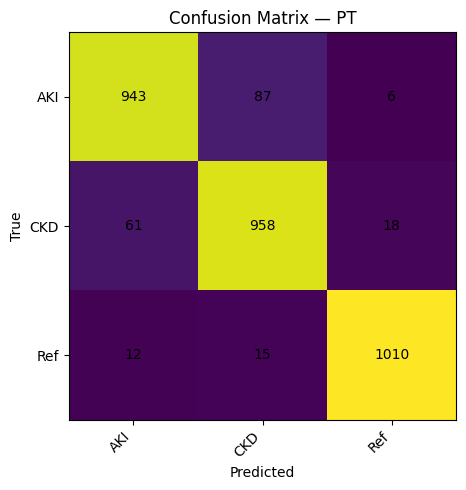

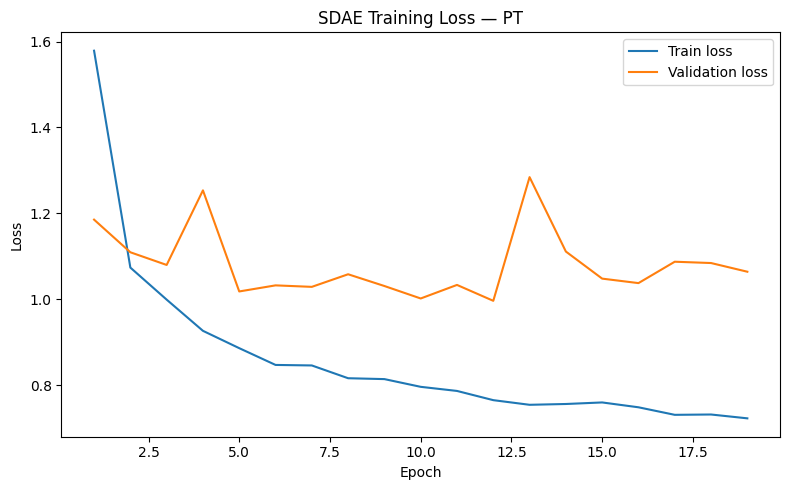

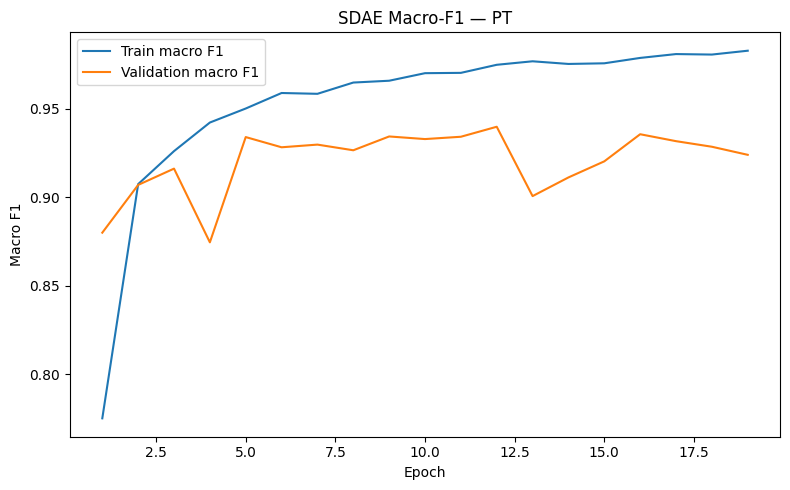

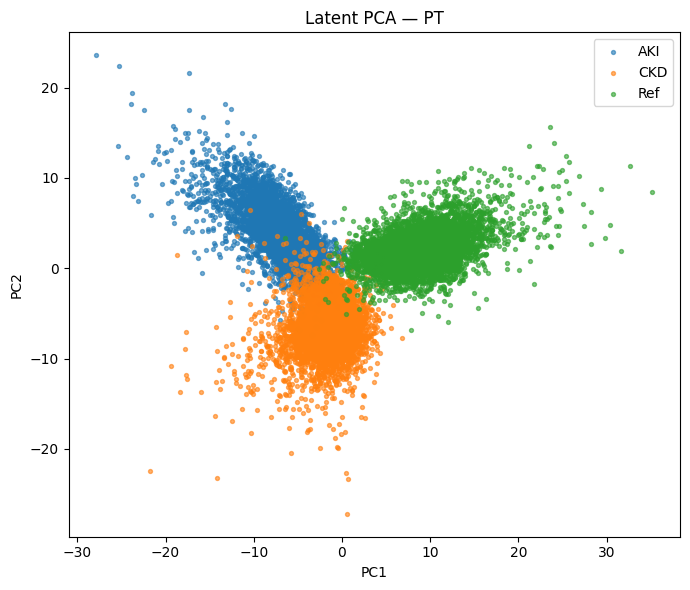

Top 10 biomarkers per class for PT


,cell_type,gene,class,importance,n_cells_used_for_importance,mean_expr_AKI,mean_expr_CKD,mean_expr_Ref,target_minus_others_mean,abs_target_minus_others_mean,combined_score
0,PT,MT-ND3,AKI,0.151146,400,98.846779,130.309601,221.295074,-76.955559,76.955559,11.631508
1,PT,MT1G,AKI,0.157366,400,57.674652,31.546890,28.643833,27.579290,27.579290,4.340032
2,PT,MT-ND2,AKI,0.152889,400,30.918463,39.163532,67.924690,-22.625648,22.625648,3.459213
3,PT,MT-ND1,AKI,0.176314,400,19.580925,27.004358,46.137325,-16.989917,16.989917,2.995565
4,PT,MT-CYB,AKI,0.135956,400,42.749382,44.782890,80.856453,-20.070290,20.070290,2.728679
5,PT,SPP1,AKI,0.087463,400,24.276987,9.201167,2.294285,18.529261,18.529261,1.620620
6,PT,MT-CO3,AKI,0.046590,400,101.646790,99.778351,166.398315,-31.441544,31.441544,1.464852
7,PT,GSTP1,AKI,0.116115,400,12.235778,4.466715,2.739438,8.632701,8.632701,1.002390
8,PT,MT-CO1,AKI,0.060927,400,170.967880,156.306610,216.849869,-15.610359,15.610359,0.951089
9,PT,MT-CO2,AKI,0.031027,400,127.863144,122.669075,184.697250,-25.820019,25.820019,0.801128


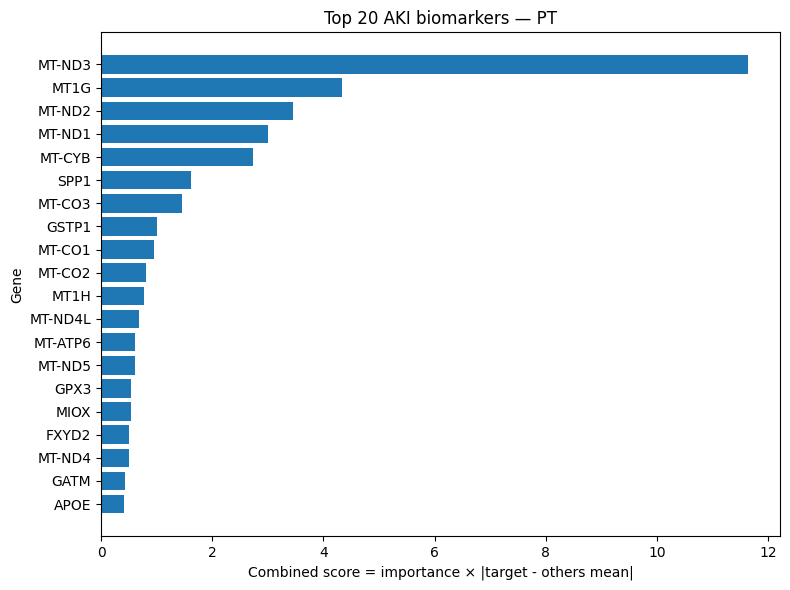

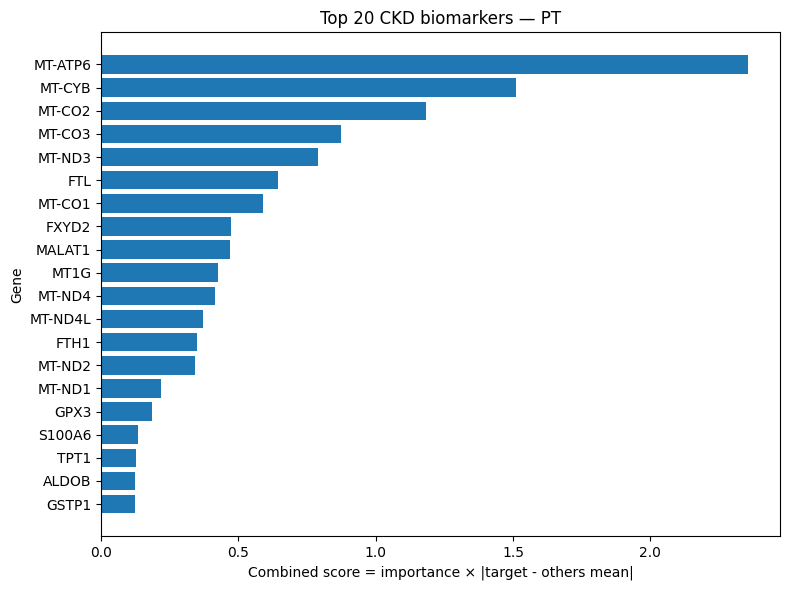

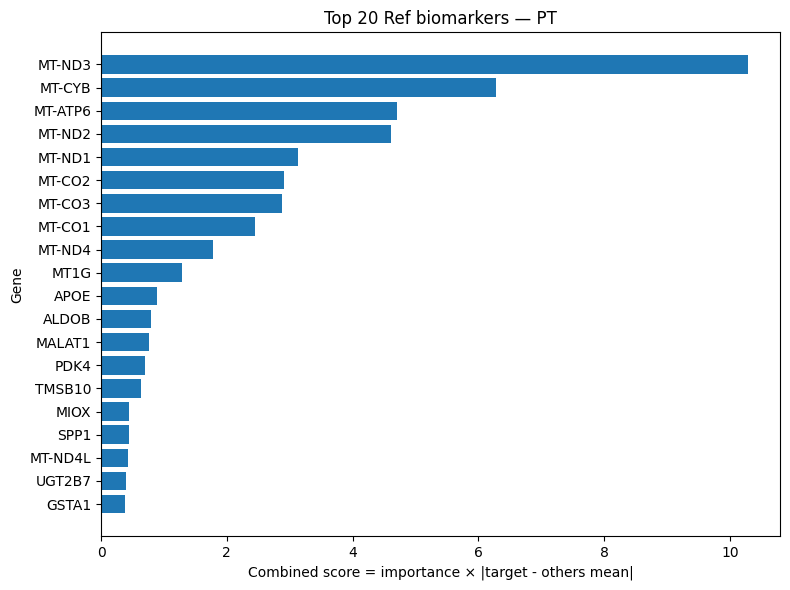

[2/8] Cell type: TAL
Original counts: {'AKI': 8930, 'CKD': 11319, 'Ref': 3645}
Sampled counts: {'AKI': 3645, 'CKD': 3645, 'Ref': 3645}
Balance reason: Ref count used
Balanced adata shape: (10935, 37080)
HVG shape: (10935, 3000)
Class names: ['AKI', 'CKD', 'Ref']
Balanced label counts:


,count
AKI,3645
CKD,3645
Ref,3645


Split counts:


,split,condition,n_cells
0,test,AKI,729
1,test,CKD,729
2,test,Ref,729
3,train,AKI,2479
4,train,CKD,2478
5,train,Ref,2478
6,validation,AKI,437
7,validation,CKD,438
8,validation,Ref,438


Epoch 001 | train_loss=1.6615, train_F1=0.7502 | val_loss=1.2102, val_F1=0.8733
Epoch 002 | train_loss=1.1084, train_F1=0.8953 | val_loss=1.0773, val_F1=0.9115
Epoch 003 | train_loss=0.9907, train_F1=0.9236 | val_loss=1.3078, val_F1=0.8345
Epoch 004 | train_loss=0.9375, train_F1=0.9358 | val_loss=1.2563, val_F1=0.8713
Epoch 005 | train_loss=0.9104, train_F1=0.9420 | val_loss=1.3081, val_F1=0.8550
Epoch 006 | train_loss=0.9087, train_F1=0.9410 | val_loss=1.4828, val_F1=0.8322
Epoch 007 | train_loss=0.8727, train_F1=0.9502 | val_loss=1.3100, val_F1=0.8668
Epoch 008 | train_loss=0.8414, train_F1=0.9540 | val_loss=1.0644, val_F1=0.9060
Epoch 009 | train_loss=0.8345, train_F1=0.9570 | val_loss=1.1601, val_F1=0.8921
Early stopping triggered
Test classification report
              precision    recall  f1-score   support

         AKI       0.89      0.87      0.88       729
         CKD       0.83      0.90      0.86       729
         Ref       0.99      0.93      0.96       729

    accura

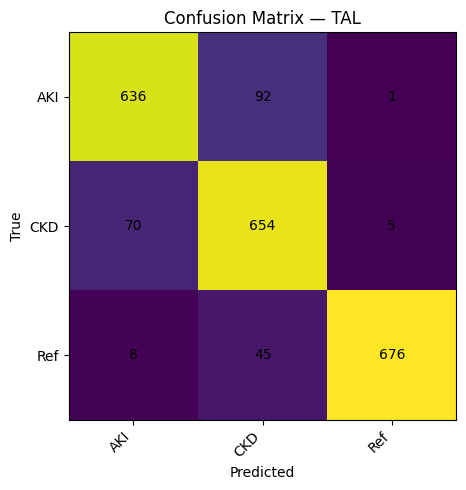

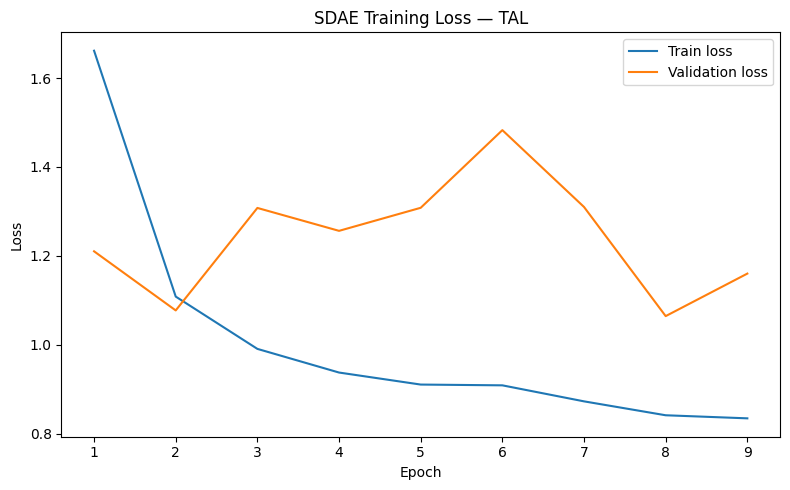

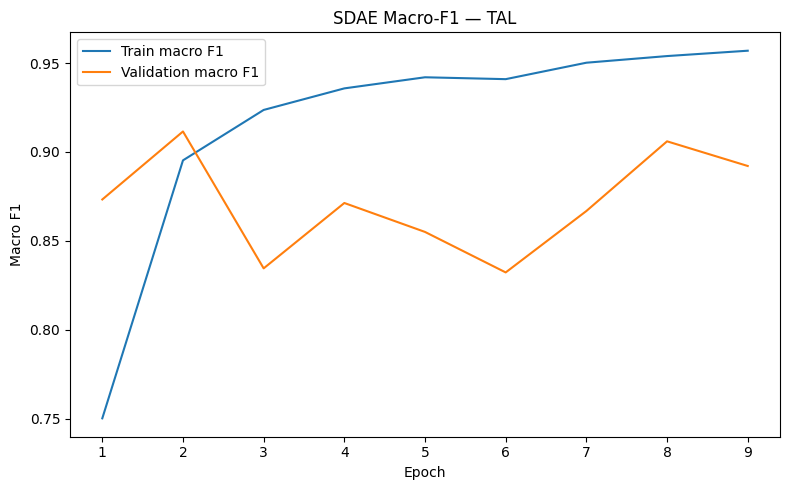

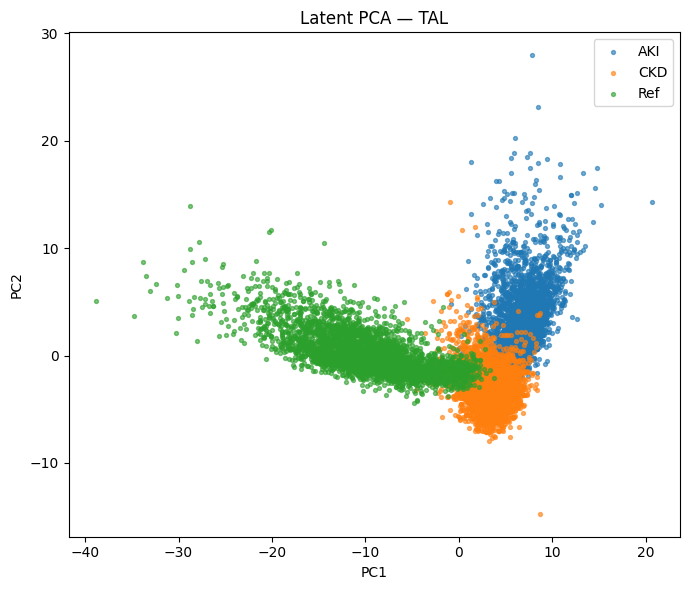

Top 10 biomarkers per class for TAL


,cell_type,gene,class,importance,n_cells_used_for_importance,mean_expr_AKI,mean_expr_CKD,mean_expr_Ref,target_minus_others_mean,abs_target_minus_others_mean,combined_score
0,TAL,MT-ND3,AKI,0.064723,400,149.014221,200.602997,460.106812,-181.340683,181.340683,11.736906
1,TAL,MT-CYB,AKI,0.075405,400,48.481354,71.383659,174.132675,-74.276814,74.276814,5.600837
2,TAL,MT-CO1,AKI,0.039648,400,161.719971,199.205231,364.825592,-120.295441,120.295441,4.769493
3,TAL,MT-ND1,AKI,0.074876,400,30.224962,52.358826,123.568321,-57.738611,57.738611,4.323246
4,TAL,MT-ND2,AKI,0.058778,400,43.076401,68.802361,147.915161,-65.282360,65.282360,3.837149
5,TAL,MT-CO3,AKI,0.041896,400,119.834099,140.008331,277.275635,-88.807884,88.807884,3.720653
6,TAL,MT-ATP6,AKI,0.021415,400,90.884117,103.325615,215.112442,-68.334911,68.334911,1.463376
7,TAL,SPP1,AKI,0.038416,400,52.633526,22.139408,8.511196,37.308224,37.308224,1.433251
8,TAL,MT-CO2,AKI,0.011020,400,148.853836,169.265259,387.473755,-129.515671,129.515671,1.427221
9,TAL,MALAT1,AKI,0.011344,400,105.561317,145.845047,303.920227,-119.321320,119.321320,1.353558


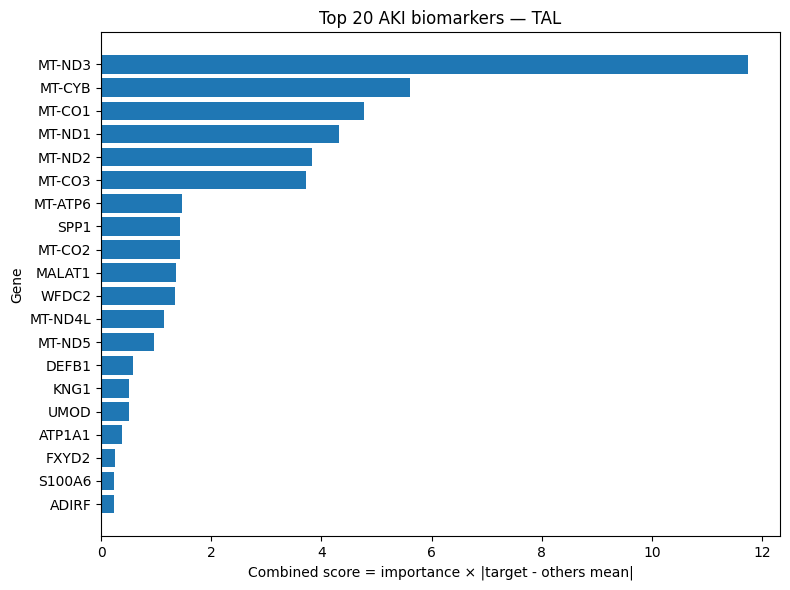

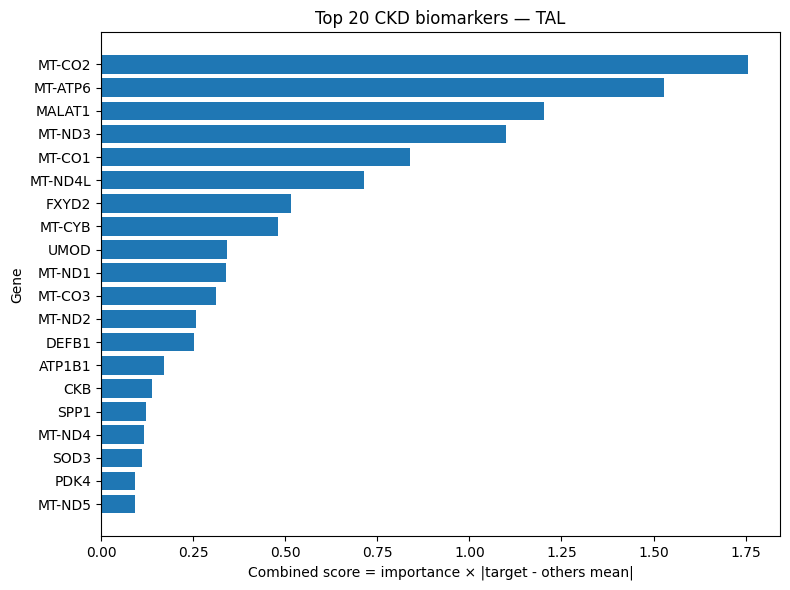

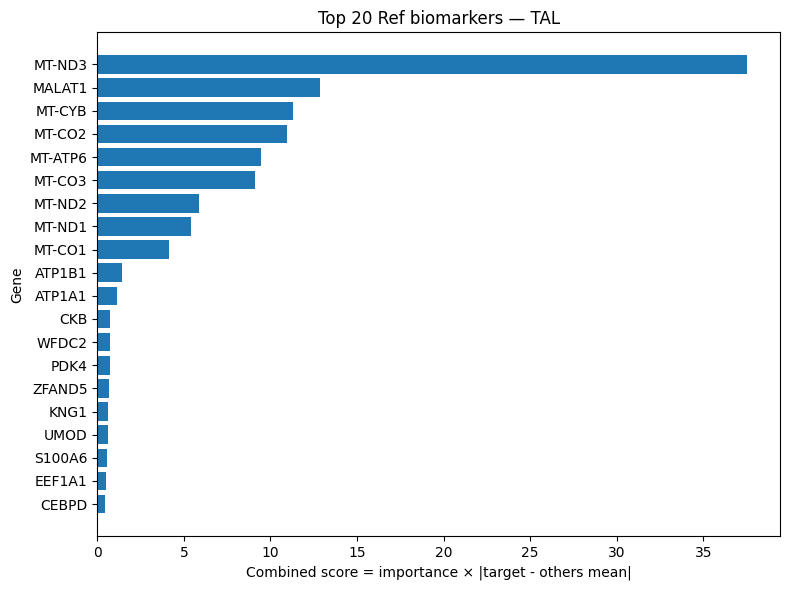

[3/8] Cell type: IMM
Original counts: {'AKI': 8819, 'CKD': 6884, 'Ref': 1473}
Sampled counts: {'AKI': 1473, 'CKD': 1473, 'Ref': 1473}
Balance reason: Ref count used
Balanced adata shape: (4419, 37080)
HVG shape: (4419, 3000)
Class names: ['AKI', 'CKD', 'Ref']
Balanced label counts:


,count
CKD,1473
AKI,1473
Ref,1473


Split counts:


,split,condition,n_cells
0,test,AKI,294
1,test,CKD,295
2,test,Ref,295
3,train,AKI,1002
4,train,CKD,1001
5,train,Ref,1001
6,validation,AKI,177
7,validation,CKD,177
8,validation,Ref,177


Epoch 001 | train_loss=2.2894, train_F1=0.5719 | val_loss=1.7193, val_F1=0.7631
Epoch 002 | train_loss=1.4292, train_F1=0.8683 | val_loss=1.5276, val_F1=0.8254
Epoch 003 | train_loss=1.0880, train_F1=0.9493 | val_loss=1.6506, val_F1=0.8268
Epoch 004 | train_loss=1.0245, train_F1=0.9581 | val_loss=1.7222, val_F1=0.8093
Epoch 005 | train_loss=0.9735, train_F1=0.9677 | val_loss=1.6762, val_F1=0.8353
Epoch 006 | train_loss=0.9324, train_F1=0.9751 | val_loss=1.7388, val_F1=0.8245
Epoch 007 | train_loss=0.9324, train_F1=0.9770 | val_loss=1.7557, val_F1=0.8177
Epoch 008 | train_loss=0.9018, train_F1=0.9780 | val_loss=1.8698, val_F1=0.8212
Epoch 009 | train_loss=0.8727, train_F1=0.9860 | val_loss=1.8670, val_F1=0.8295
Epoch 010 | train_loss=0.8713, train_F1=0.9820 | val_loss=1.9467, val_F1=0.8274
Epoch 011 | train_loss=0.8552, train_F1=0.9850 | val_loss=1.8835, val_F1=0.8316
Epoch 012 | train_loss=0.8432, train_F1=0.9867 | val_loss=1.9208, val_F1=0.8274
Early stopping triggered
Test classifica

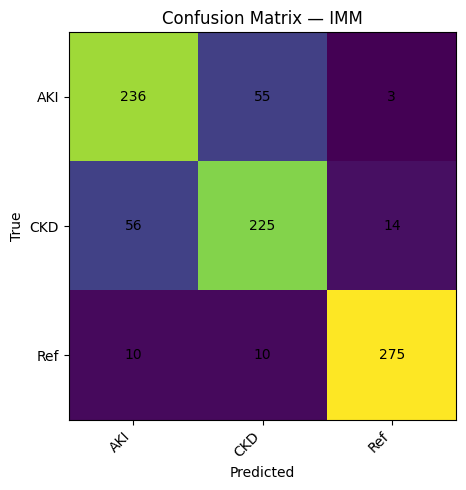

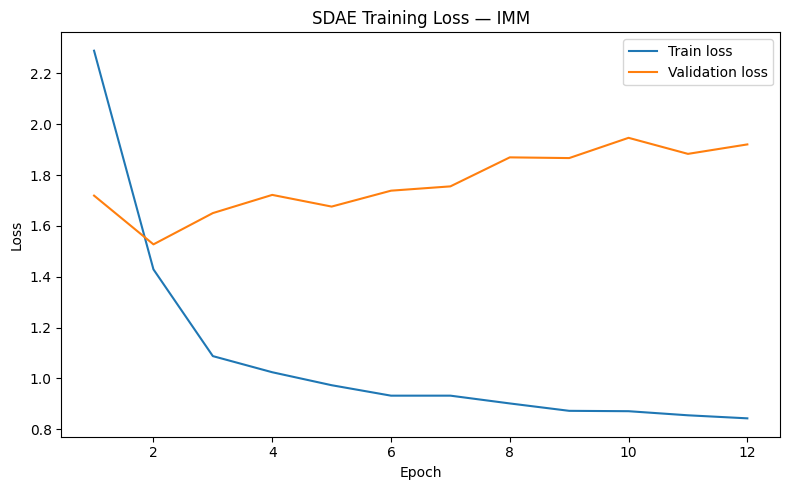

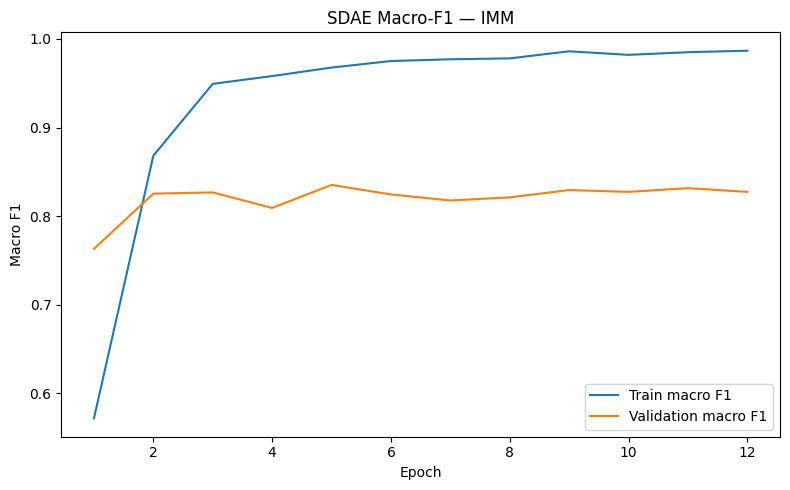

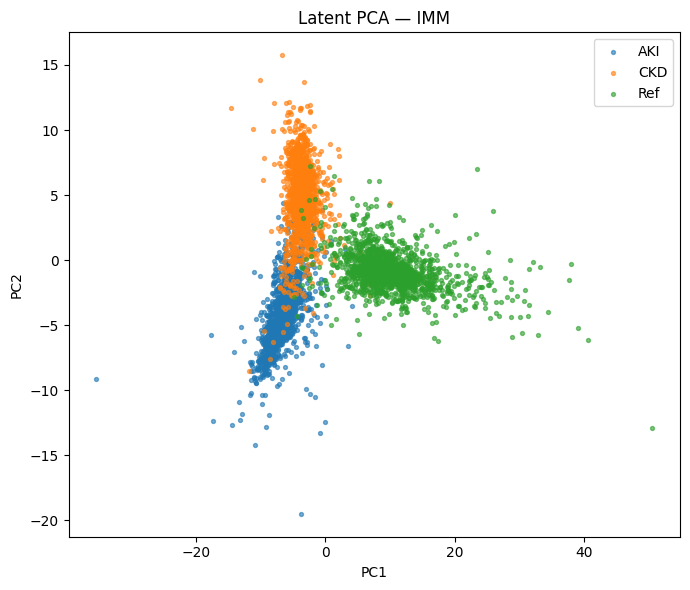

Top 10 biomarkers per class for IMM


,cell_type,gene,class,importance,n_cells_used_for_importance,mean_expr_AKI,mean_expr_CKD,mean_expr_Ref,target_minus_others_mean,abs_target_minus_others_mean,combined_score
0,IMM,MT-ND3,AKI,0.103919,400,48.515110,80.035637,121.366920,-52.186169,52.186169,5.423113
1,IMM,MT-ND2,AKI,0.122066,400,14.433301,25.906860,34.550961,-15.795609,15.795609,1.928103
2,IMM,MALAT1,AKI,0.054181,400,47.940025,55.033447,100.046326,-29.599861,29.599861,1.603740
3,IMM,MT-ND1,AKI,0.131628,400,9.212602,16.572678,23.286173,-10.716824,10.716824,1.410631
4,IMM,MT-CYB,AKI,0.064389,400,21.010742,28.311798,46.395939,-16.343126,16.343126,1.052316
5,IMM,MT-ND4L,AKI,0.112304,400,6.569796,16.295216,13.928274,-8.541949,8.541949,0.959293
6,IMM,MT-CO3,AKI,0.032560,400,37.678158,51.170017,73.732368,-24.773035,24.773035,0.806612
7,IMM,RPS27,AKI,0.098570,400,17.095297,19.780935,27.861181,-6.725761,6.725761,0.662955
8,IMM,MT-CO1,AKI,0.027384,400,73.924324,87.383598,104.299751,-21.917351,21.917351,0.600175
9,IMM,MT-ND5,AKI,0.104543,400,6.133570,11.295919,12.040167,-5.534473,5.534473,0.578593


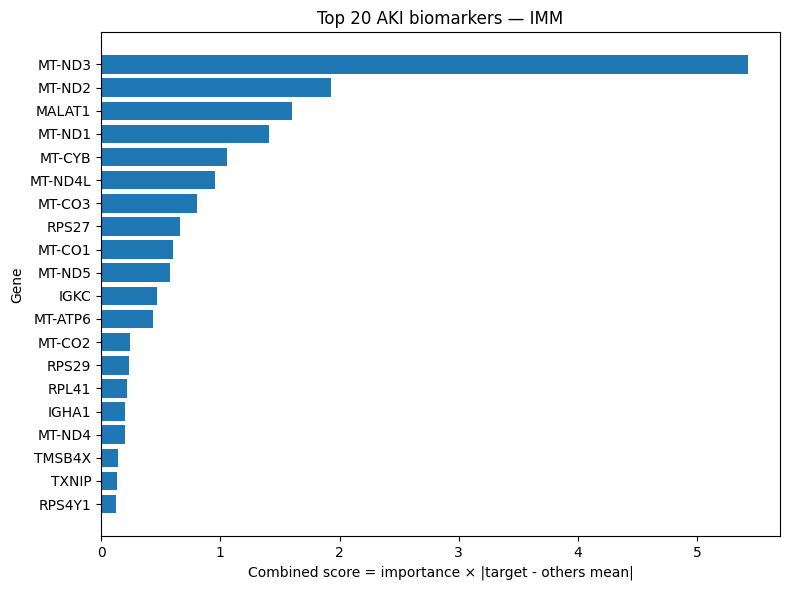

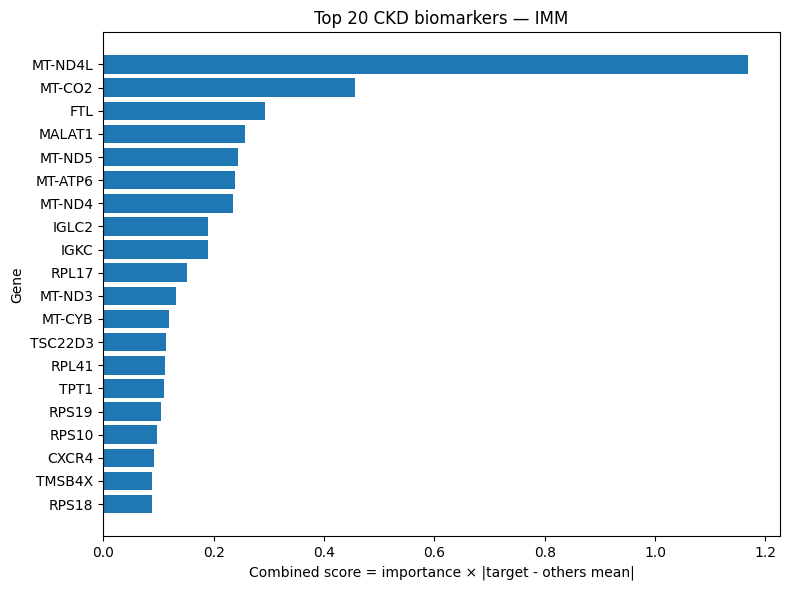

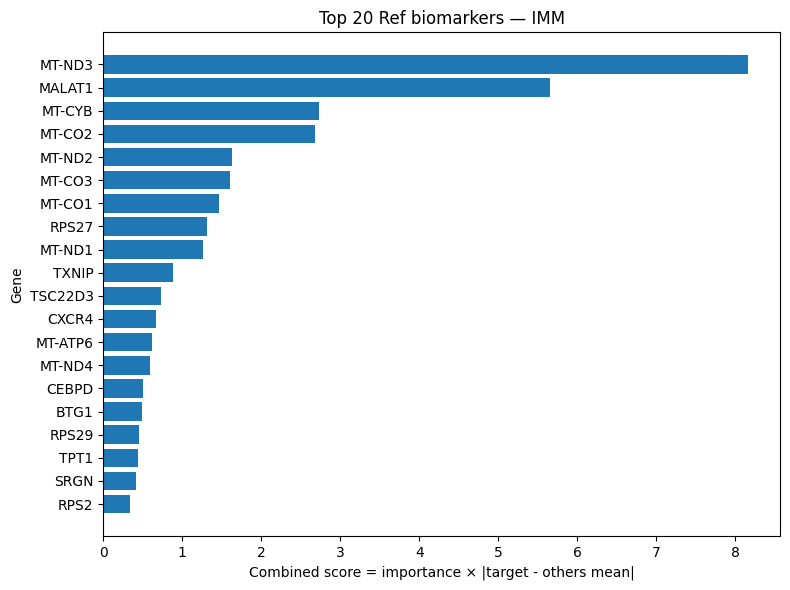

[4/8] Cell type: EC
Original counts: {'AKI': 1915, 'CKD': 3905, 'Ref': 2730}
Sampled counts: {'AKI': 1915, 'CKD': 1915, 'Ref': 1915}
Balance reason: minimum condition count used
Balanced adata shape: (5745, 37080)
HVG shape: (5745, 3000)
Class names: ['AKI', 'CKD', 'Ref']
Balanced label counts:


,count
CKD,1915
Ref,1915
AKI,1915


Split counts:


,split,condition,n_cells
0,test,AKI,383
1,test,CKD,383
2,test,Ref,383
3,train,AKI,1302
4,train,CKD,1302
5,train,Ref,1302
6,validation,AKI,230
7,validation,CKD,230
8,validation,Ref,230


Epoch 001 | train_loss=2.0801, train_F1=0.6007 | val_loss=1.5526, val_F1=0.7873
Epoch 002 | train_loss=1.3162, train_F1=0.8770 | val_loss=1.3429, val_F1=0.8564
Epoch 003 | train_loss=1.0757, train_F1=0.9406 | val_loss=1.4320, val_F1=0.8345
Epoch 004 | train_loss=1.0070, train_F1=0.9496 | val_loss=1.3469, val_F1=0.8660
Epoch 005 | train_loss=0.9657, train_F1=0.9641 | val_loss=1.4982, val_F1=0.8532
Epoch 006 | train_loss=0.9075, train_F1=0.9731 | val_loss=1.6349, val_F1=0.8393
Epoch 007 | train_loss=0.9032, train_F1=0.9723 | val_loss=1.4573, val_F1=0.8593
Epoch 008 | train_loss=0.8986, train_F1=0.9739 | val_loss=1.5936, val_F1=0.8551
Epoch 009 | train_loss=0.8761, train_F1=0.9790 | val_loss=1.4785, val_F1=0.8626
Epoch 010 | train_loss=0.8653, train_F1=0.9805 | val_loss=1.5309, val_F1=0.8691
Epoch 011 | train_loss=0.8404, train_F1=0.9852 | val_loss=1.5949, val_F1=0.8536
Epoch 012 | train_loss=0.8203, train_F1=0.9887 | val_loss=1.6983, val_F1=0.8650
Epoch 013 | train_loss=0.8213, train_F1=

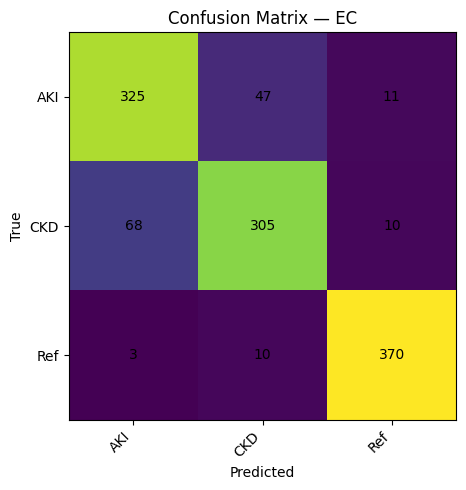

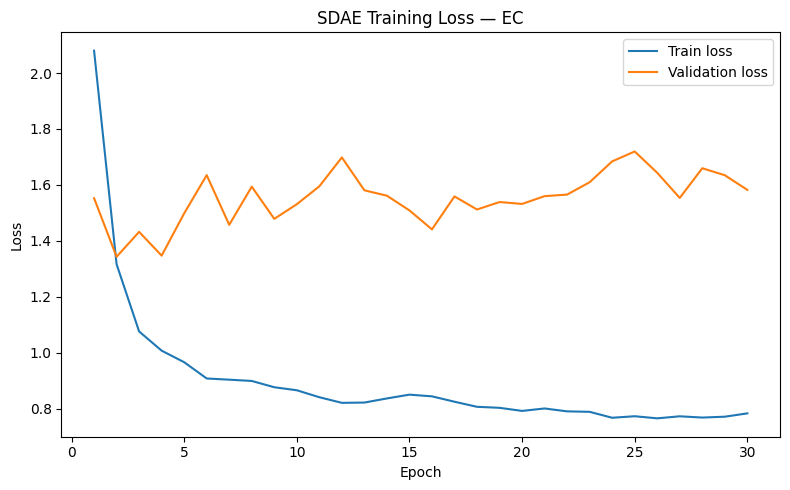

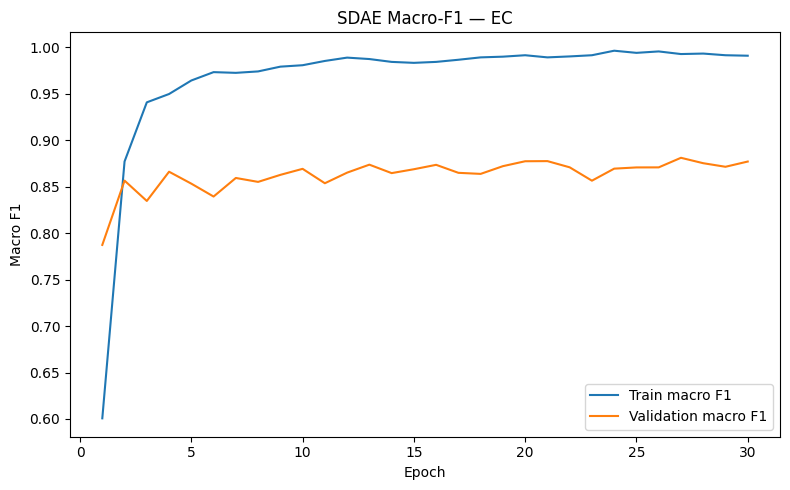

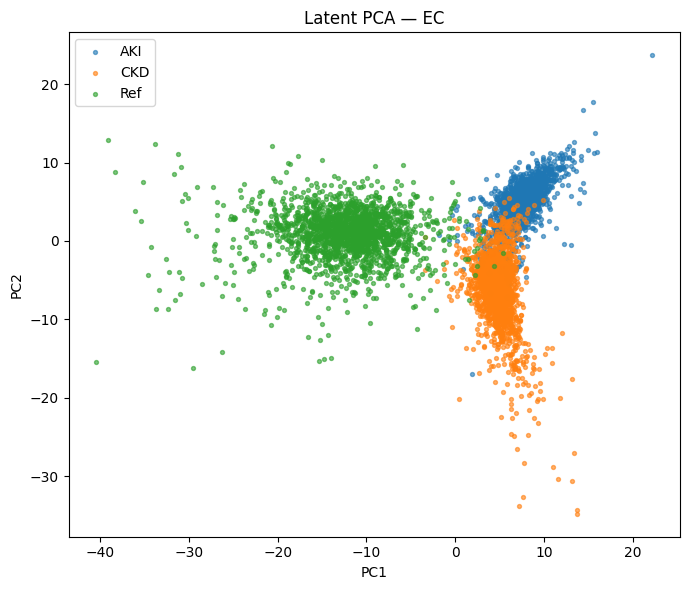

Top 10 biomarkers per class for EC


,cell_type,gene,class,importance,n_cells_used_for_importance,mean_expr_AKI,mean_expr_CKD,mean_expr_Ref,target_minus_others_mean,abs_target_minus_others_mean,combined_score
0,EC,MT-ND3,AKI,0.148042,400,72.291214,88.574997,146.568771,-45.280670,45.280670,6.703460
1,EC,MT-CO3,AKI,0.104843,400,47.932518,53.307022,85.746109,-21.594048,21.594048,2.263980
2,EC,MT-ND2,AKI,0.155437,400,21.284578,28.833263,42.675529,-14.469818,14.469818,2.249141
3,EC,MT-ND1,AKI,0.172804,400,13.219269,19.456408,27.832937,-10.425404,10.425404,1.801549
4,EC,MT-CYB,AKI,0.092851,400,26.414228,29.845713,53.653515,-15.335385,15.335385,1.423912
5,EC,MT-CO1,AKI,0.062479,400,79.796661,82.957619,113.680016,-18.522156,18.522156,1.157250
6,EC,MT-CO2,AKI,0.052815,400,71.080215,68.685295,112.111610,-19.318237,19.318237,1.020296
7,EC,MT-ATP6,AKI,0.098695,400,61.090130,56.066628,84.258064,-9.072216,9.072216,0.895381
8,EC,MT-ND4L,AKI,0.143025,400,11.309987,16.971809,17.796839,-6.074337,6.074337,0.868779
9,EC,MALAT1,AKI,0.021207,400,49.899372,58.604961,107.734489,-33.270353,33.270353,0.705564


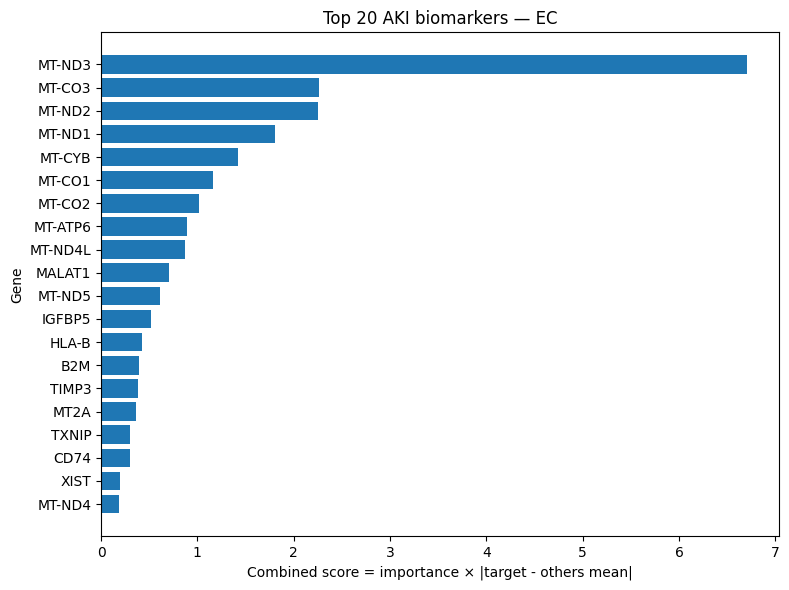

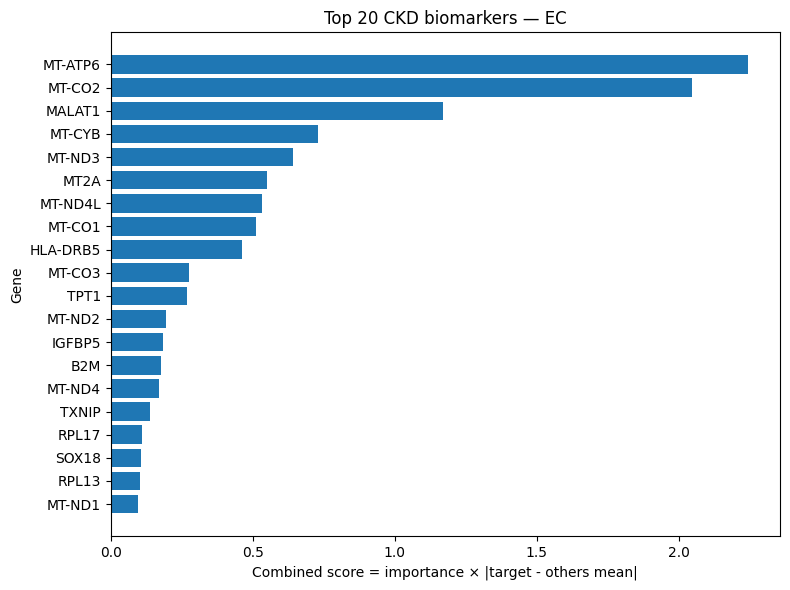

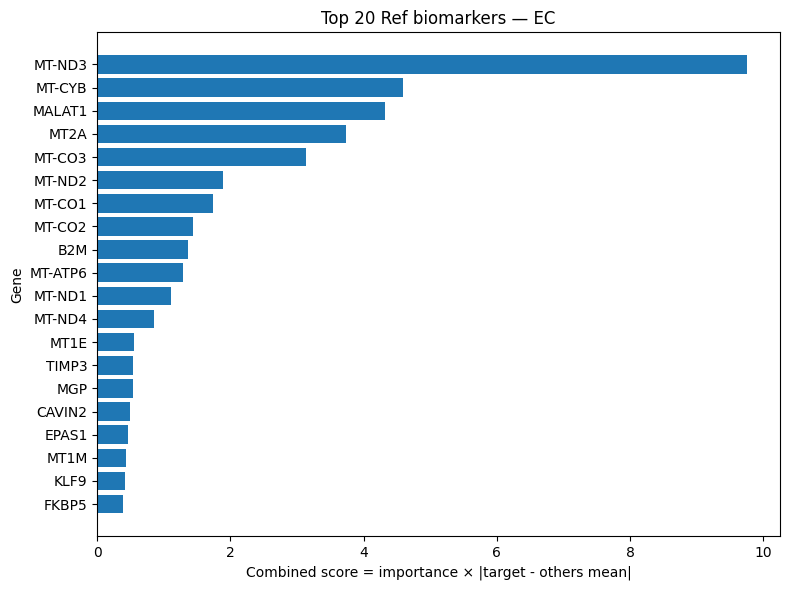

[5/8] Cell type: IC
Original counts: {'AKI': 1110, 'CKD': 5023, 'Ref': 2201}
Sampled counts: {'AKI': 1110, 'CKD': 1110, 'Ref': 1110}
Balance reason: minimum condition count used
Balanced adata shape: (3330, 37080)
HVG shape: (3330, 3000)
Class names: ['AKI', 'CKD', 'Ref']
Balanced label counts:


,count
AKI,1110
CKD,1110
Ref,1110


Split counts:


,split,condition,n_cells
0,test,AKI,222
1,test,CKD,222
2,test,Ref,222
3,train,AKI,755
4,train,CKD,755
5,train,Ref,754
6,validation,AKI,133
7,validation,CKD,133
8,validation,Ref,134


Epoch 001 | train_loss=2.2026, train_F1=0.6094 | val_loss=1.6414, val_F1=0.8129
Epoch 002 | train_loss=1.3510, train_F1=0.8649 | val_loss=1.2724, val_F1=0.8566
Epoch 003 | train_loss=1.0023, train_F1=0.9279 | val_loss=1.3207, val_F1=0.8232
Epoch 004 | train_loss=0.8743, train_F1=0.9576 | val_loss=1.3469, val_F1=0.8428
Epoch 005 | train_loss=0.8112, train_F1=0.9740 | val_loss=1.1129, val_F1=0.9105
Epoch 006 | train_loss=0.8339, train_F1=0.9624 | val_loss=1.4611, val_F1=0.8590
Epoch 007 | train_loss=0.8122, train_F1=0.9709 | val_loss=1.2052, val_F1=0.8888
Epoch 008 | train_loss=0.7955, train_F1=0.9682 | val_loss=1.3940, val_F1=0.8566
Epoch 009 | train_loss=0.7973, train_F1=0.9749 | val_loss=1.0886, val_F1=0.9172
Epoch 010 | train_loss=0.7331, train_F1=0.9854 | val_loss=1.0781, val_F1=0.9227
Epoch 011 | train_loss=0.7303, train_F1=0.9819 | val_loss=1.0947, val_F1=0.9068
Epoch 012 | train_loss=0.7449, train_F1=0.9779 | val_loss=1.2581, val_F1=0.8872
Epoch 013 | train_loss=0.7429, train_F1=

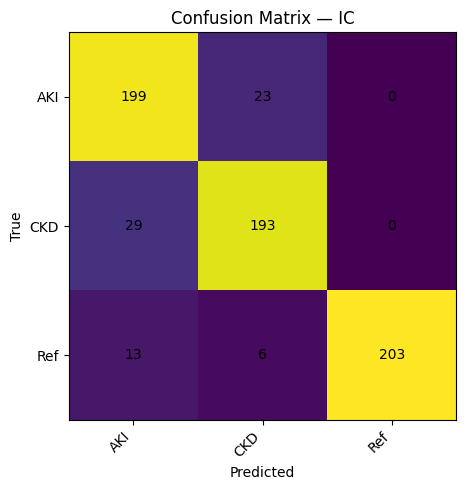

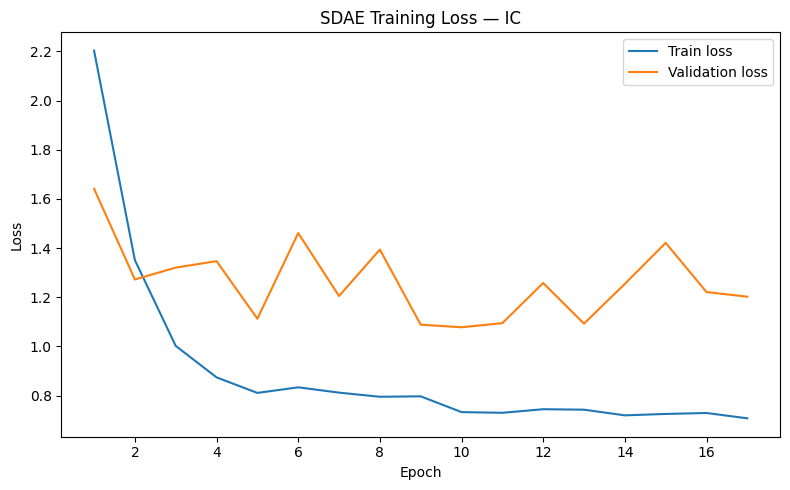

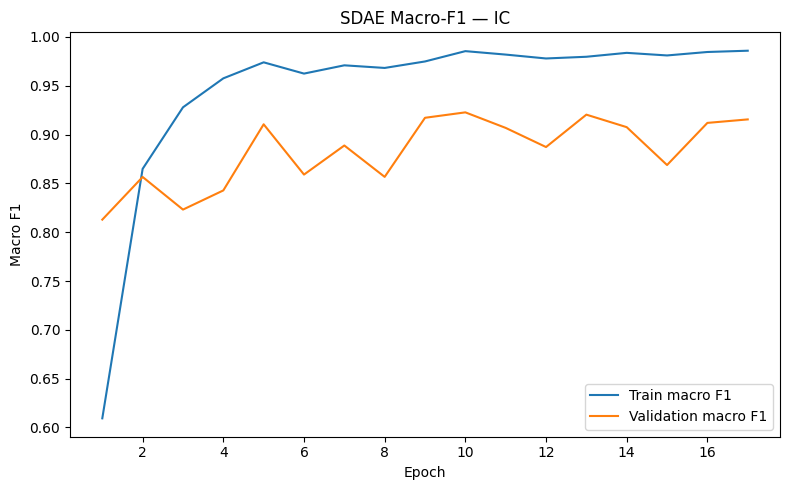

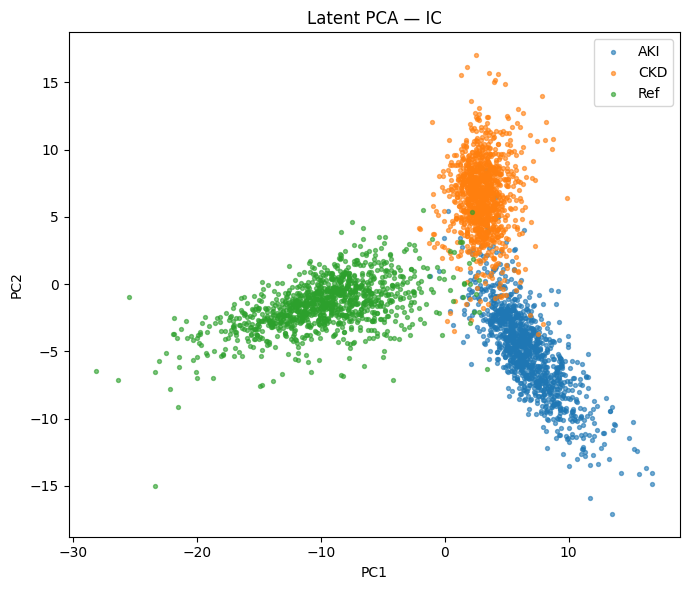

Top 10 biomarkers per class for IC


,cell_type,gene,class,importance,n_cells_used_for_importance,mean_expr_AKI,mean_expr_CKD,mean_expr_Ref,target_minus_others_mean,abs_target_minus_others_mean,combined_score
0,IC,MT-ND3,AKI,0.037959,400,182.626038,172.414551,448.776306,-127.969391,127.969391,4.857616
1,IC,MT-CO3,AKI,0.049270,400,127.970802,129.953201,268.174530,-71.093063,71.093063,3.502744
2,IC,WFDC2,AKI,0.081811,400,36.526966,13.867877,12.044047,23.571004,23.571004,1.928359
3,IC,SPP1,AKI,0.069909,400,26.636858,2.940641,1.547588,24.392743,24.392743,1.705266
4,IC,MT-CO1,AKI,0.019700,400,236.629166,200.962555,431.818848,-79.761536,79.761536,1.571332
5,IC,MT-ND2,AKI,0.041878,400,45.354656,48.681210,111.517242,-34.744570,34.744570,1.455041
6,IC,MT-CO2,AKI,0.011689,400,213.857391,172.914871,449.348907,-97.274498,97.274498,1.137031
7,IC,MT-CYB,AKI,0.024164,400,66.408600,58.330578,162.628723,-44.071051,44.071051,1.064944
8,IC,MALAT1,AKI,0.013769,400,130.952972,107.495262,307.918549,-76.753933,76.753933,1.056796
9,IC,MT-ND1,AKI,0.034910,400,36.128441,36.770008,93.624321,-29.068724,29.068724,1.014778


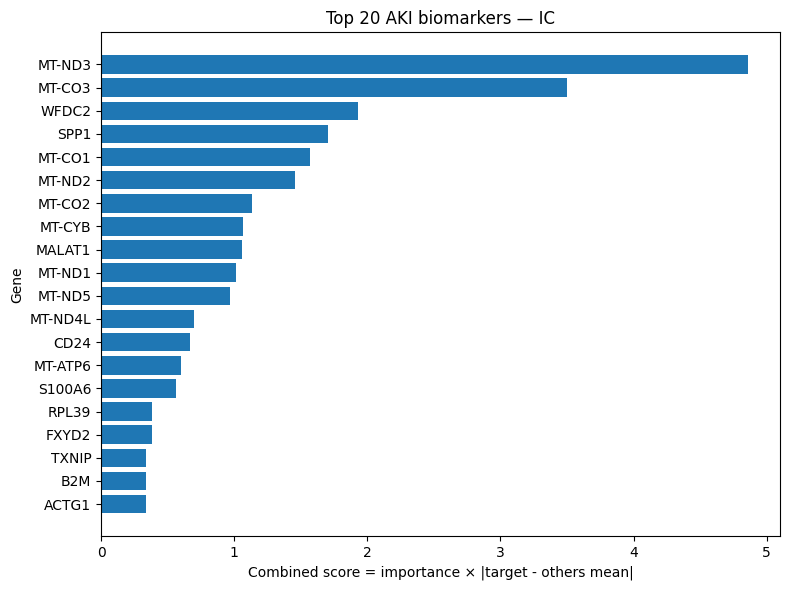

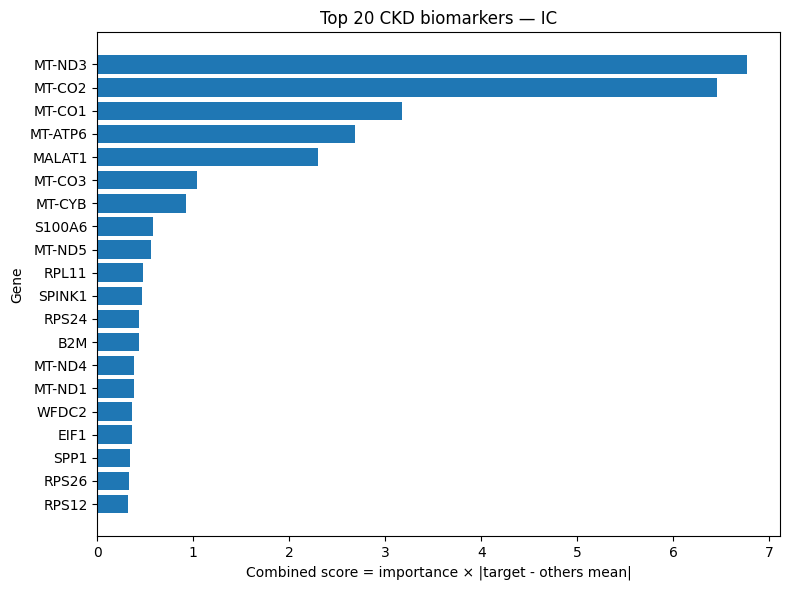

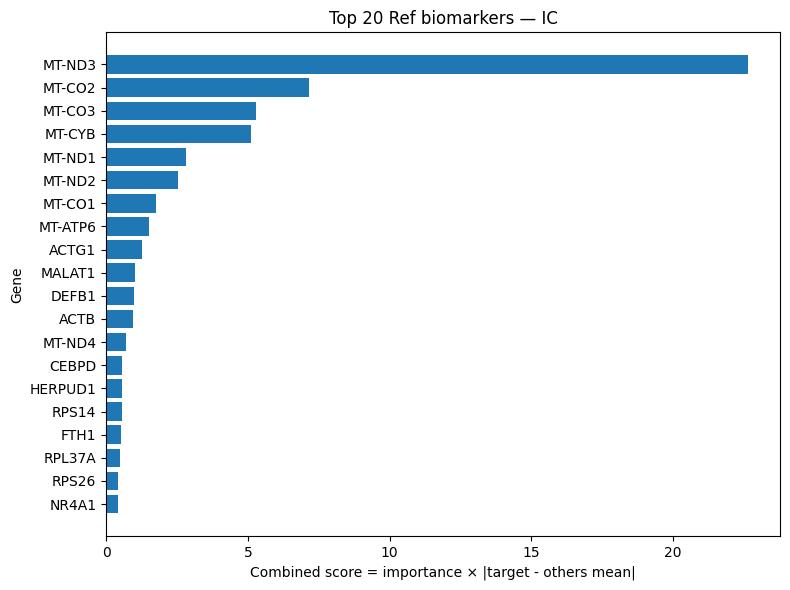

[6/8] Cell type: PC
Original counts: {'AKI': 2025, 'CKD': 4632, 'Ref': 826}
Sampled counts: {'AKI': 826, 'CKD': 826, 'Ref': 826}
Balance reason: Ref count used
Balanced adata shape: (2478, 37080)
HVG shape: (2478, 3000)
Class names: ['AKI', 'CKD', 'Ref']
Balanced label counts:


,count
Ref,826
CKD,826
AKI,826


Split counts:


,split,condition,n_cells
0,test,AKI,165
1,test,CKD,165
2,test,Ref,166
3,train,AKI,561
4,train,CKD,562
5,train,Ref,561
6,validation,AKI,100
7,validation,CKD,99
8,validation,Ref,99


Epoch 001 | train_loss=2.2909, train_F1=0.5647 | val_loss=1.8097, val_F1=0.8363
Epoch 002 | train_loss=1.5725, train_F1=0.8328 | val_loss=1.4670, val_F1=0.8034
Epoch 003 | train_loss=1.1555, train_F1=0.9110 | val_loss=1.1787, val_F1=0.8916
Epoch 004 | train_loss=0.9249, train_F1=0.9543 | val_loss=1.2877, val_F1=0.8694
Epoch 005 | train_loss=0.8439, train_F1=0.9768 | val_loss=1.4284, val_F1=0.8422
Epoch 006 | train_loss=0.8587, train_F1=0.9691 | val_loss=1.9689, val_F1=0.8273
Epoch 007 | train_loss=0.8708, train_F1=0.9597 | val_loss=1.3539, val_F1=0.8708
Epoch 008 | train_loss=0.8325, train_F1=0.9726 | val_loss=1.2940, val_F1=0.8712
Epoch 009 | train_loss=0.7946, train_F1=0.9798 | val_loss=1.5124, val_F1=0.8450
Epoch 010 | train_loss=0.8054, train_F1=0.9757 | val_loss=1.7022, val_F1=0.8346
Early stopping triggered
Test classification report
              precision    recall  f1-score   support

         AKI       0.86      0.87      0.87       165
         CKD       0.87      0.86      

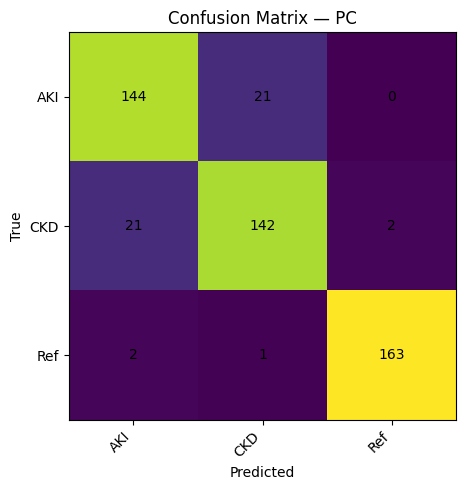

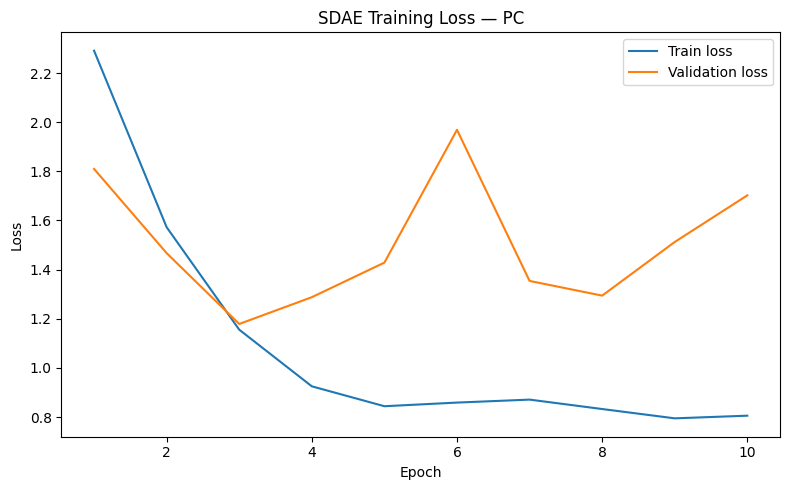

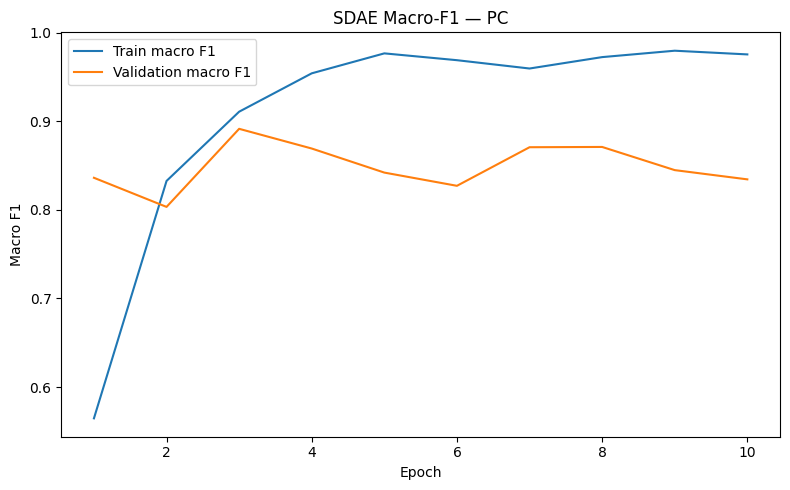

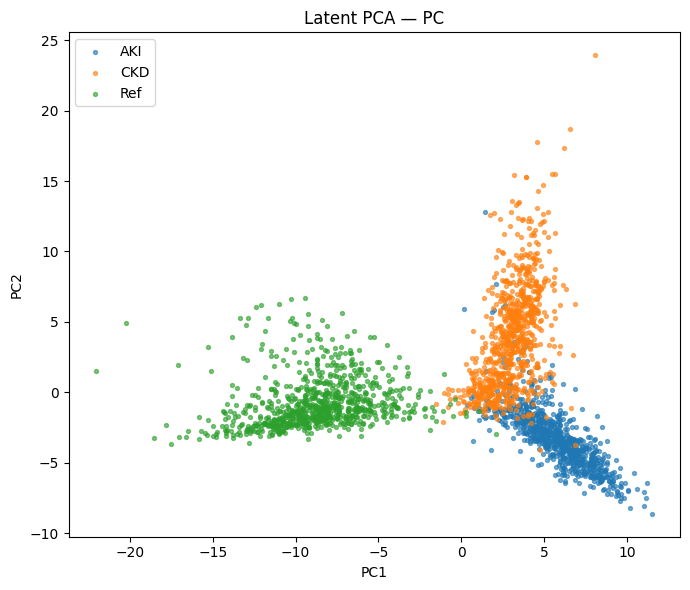

Top 10 biomarkers per class for PC


,cell_type,gene,class,importance,n_cells_used_for_importance,mean_expr_AKI,mean_expr_CKD,mean_expr_Ref,target_minus_others_mean,abs_target_minus_others_mean,combined_score
0,PC,MT-ND3,AKI,0.044487,400,118.995102,158.799728,349.056000,-134.932762,134.932762,6.002763
1,PC,MT-CO1,AKI,0.030760,400,181.161041,223.919922,434.921387,-148.259613,148.259613,4.560395
2,PC,MT-CO3,AKI,0.030329,400,112.278778,134.127869,249.910324,-79.740318,79.740318,2.418436
3,PC,MT-CO2,AKI,0.015061,400,158.769226,169.461319,411.237091,-131.579979,131.579979,1.981666
4,PC,MT-CYB,AKI,0.031607,400,56.099312,72.663948,162.993790,-61.729557,61.729557,1.951112
5,PC,MT-ND2,AKI,0.035289,400,41.834995,59.774208,111.830490,-43.967354,43.967354,1.551570
6,PC,MALAT1,AKI,0.011842,400,129.013229,192.474655,324.445862,-129.447029,129.447029,1.532952
7,PC,MT-ND1,AKI,0.035732,400,31.620050,45.126049,85.087822,-33.486885,33.486885,1.196541
8,PC,MT-ND4,AKI,0.015359,400,90.849358,110.116768,172.094055,-50.256054,50.256054,0.771879
9,PC,WFDC2,AKI,0.058988,400,30.049665,20.526545,16.371201,11.600793,11.600793,0.684308


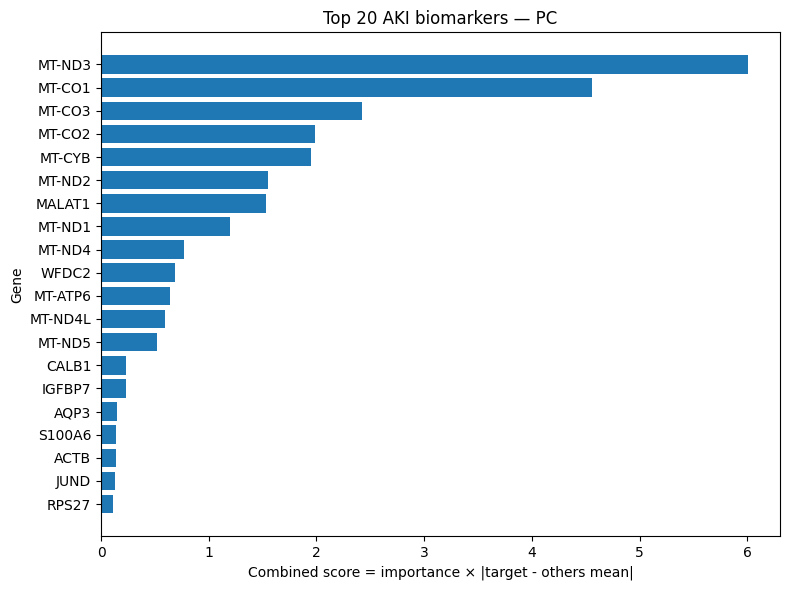

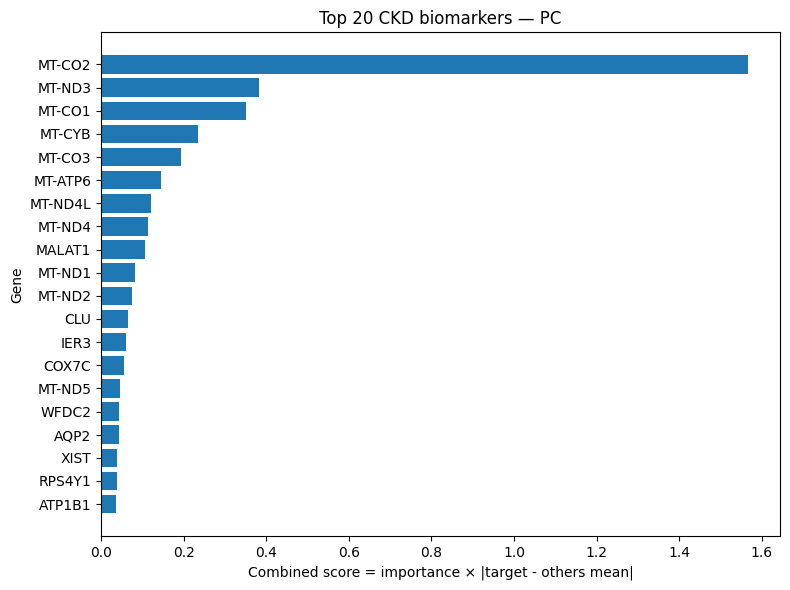

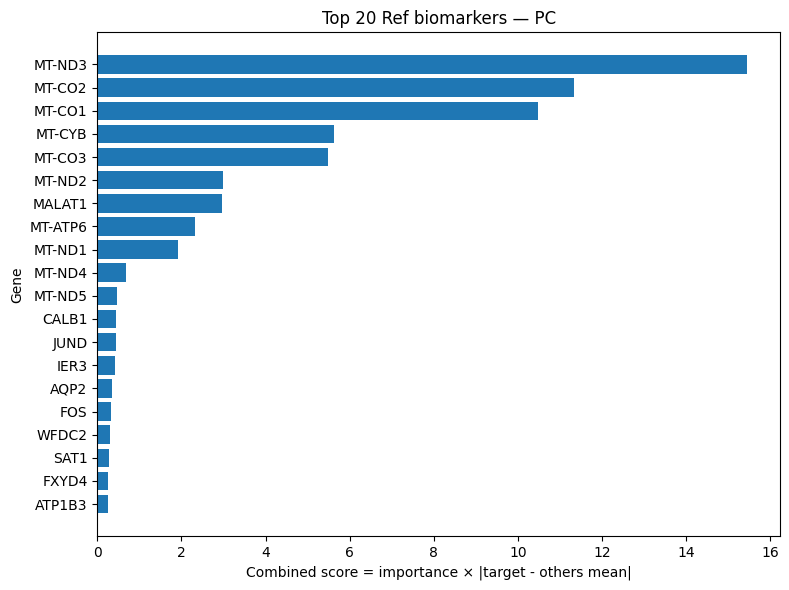

[7/8] Cell type: CNT
Original counts: {'AKI': 1583, 'CKD': 2705, 'Ref': 2171}
Sampled counts: {'AKI': 1583, 'CKD': 1583, 'Ref': 1583}
Balance reason: minimum condition count used
Balanced adata shape: (4749, 37080)
HVG shape: (4749, 3000)
Class names: ['AKI', 'CKD', 'Ref']
Balanced label counts:


,count
AKI,1583
Ref,1583
CKD,1583


Split counts:


,split,condition,n_cells
0,test,AKI,316
1,test,CKD,317
2,test,Ref,317
3,train,AKI,1077
4,train,CKD,1076
5,train,Ref,1076
6,validation,AKI,190
7,validation,CKD,190
8,validation,Ref,190


Epoch 001 | train_loss=1.9368, train_F1=0.7338 | val_loss=1.2531, val_F1=0.8843
Epoch 002 | train_loss=1.1101, train_F1=0.9213 | val_loss=1.1069, val_F1=0.9195
Epoch 003 | train_loss=0.9022, train_F1=0.9626 | val_loss=1.0426, val_F1=0.9196
Epoch 004 | train_loss=0.8704, train_F1=0.9647 | val_loss=1.0117, val_F1=0.9171
Epoch 005 | train_loss=0.8475, train_F1=0.9694 | val_loss=1.0423, val_F1=0.9151
Epoch 006 | train_loss=0.8020, train_F1=0.9780 | val_loss=1.3009, val_F1=0.8513
Epoch 007 | train_loss=0.7921, train_F1=0.9780 | val_loss=0.9863, val_F1=0.9218
Epoch 008 | train_loss=0.7834, train_F1=0.9790 | val_loss=1.0498, val_F1=0.9192
Epoch 009 | train_loss=0.7578, train_F1=0.9851 | val_loss=1.2413, val_F1=0.8997
Epoch 010 | train_loss=0.7601, train_F1=0.9845 | val_loss=1.2947, val_F1=0.8908
Epoch 011 | train_loss=0.7717, train_F1=0.9805 | val_loss=1.2571, val_F1=0.8945
Epoch 012 | train_loss=0.7915, train_F1=0.9783 | val_loss=1.6119, val_F1=0.8580
Epoch 013 | train_loss=0.8096, train_F1=

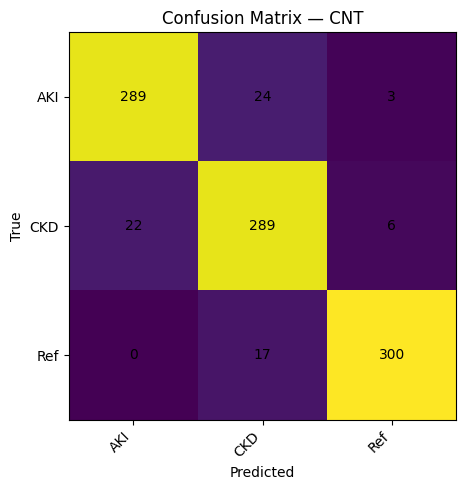

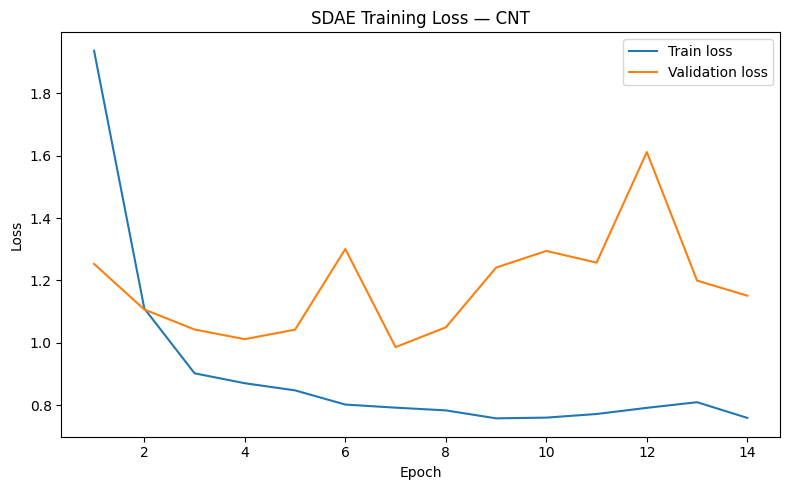

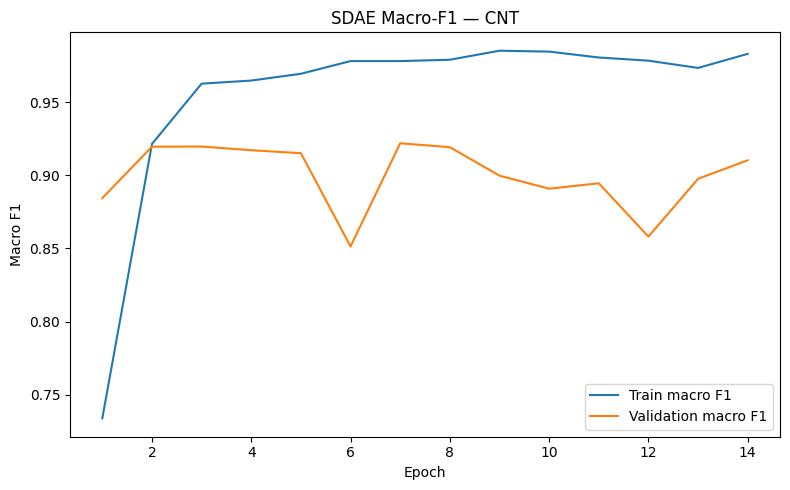

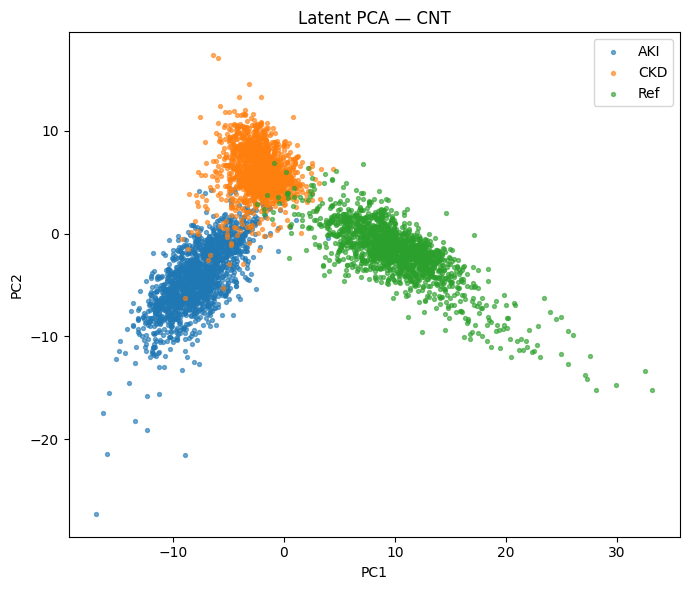

Top 10 biomarkers per class for CNT


,cell_type,gene,class,importance,n_cells_used_for_importance,mean_expr_AKI,mean_expr_CKD,mean_expr_Ref,target_minus_others_mean,abs_target_minus_others_mean,combined_score
0,CNT,MT-ND3,AKI,0.064779,400,155.069000,143.684448,378.912323,-106.229385,106.229385,6.881466
1,CNT,SPP1,AKI,0.097898,400,50.981129,6.851760,2.027039,46.541729,46.541729,4.556365
2,CNT,WFDC2,AKI,0.068767,400,58.799313,13.060884,11.743981,46.396880,46.396880,3.190583
3,CNT,MT-CO3,AKI,0.047330,400,127.729607,117.221931,254.579010,-58.170864,58.170864,2.753204
4,CNT,MT-CO2,AKI,0.025950,400,206.341171,157.934662,425.873627,-85.562973,85.562973,2.220388
5,CNT,MT-CYB,AKI,0.047511,400,64.252464,50.885052,155.987915,-39.184019,39.184019,1.861674
6,CNT,MT-ND1,AKI,0.073403,400,34.435688,30.528896,82.748047,-22.202784,22.202784,1.629740
7,CNT,MT-ND4L,AKI,0.099280,400,19.646067,28.157045,42.289970,-15.577441,15.577441,1.546534
8,CNT,MT-ND2,AKI,0.050584,400,44.468189,39.164669,100.735725,-25.482008,25.482008,1.288986
9,CNT,ATP1B1,AKI,0.065178,400,17.333574,24.892464,42.848297,-16.536806,16.536806,1.077829


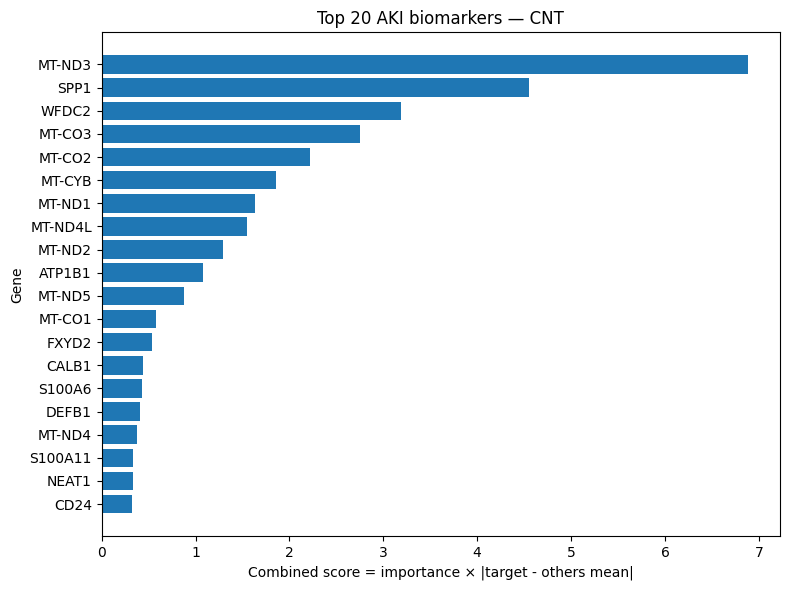

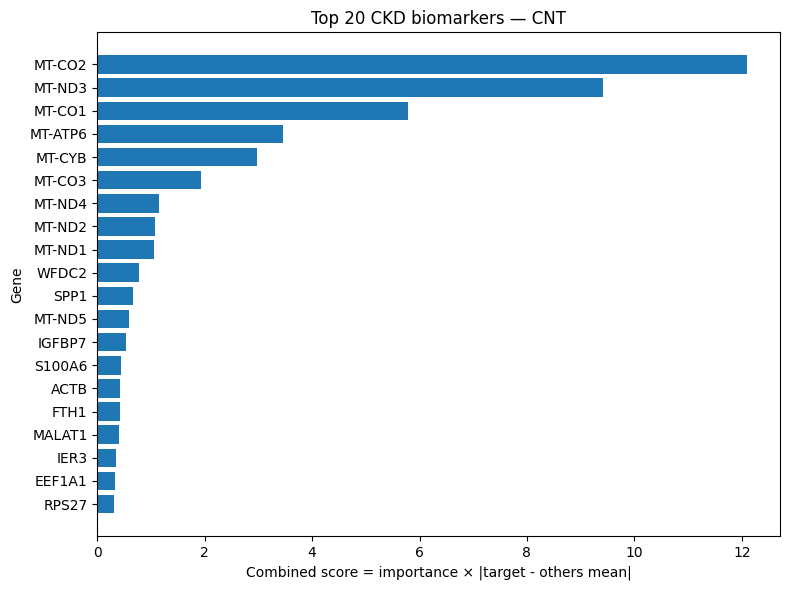

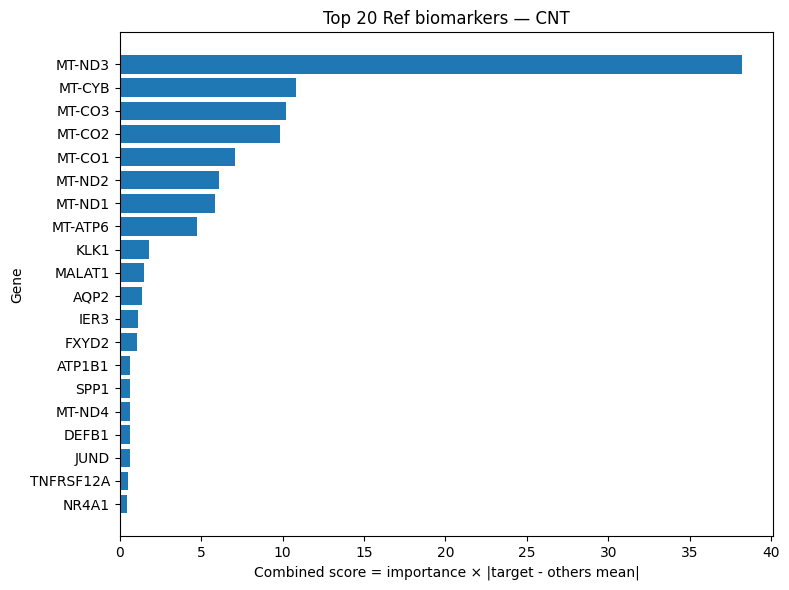

[8/8] Cell type: DCT
Original counts: {'AKI': 824, 'CKD': 2694, 'Ref': 1806}
Sampled counts: {'AKI': 824, 'CKD': 824, 'Ref': 824}
Balance reason: minimum condition count used
Balanced adata shape: (2472, 37080)
HVG shape: (2472, 3000)
Class names: ['AKI', 'CKD', 'Ref']
Balanced label counts:


,count
AKI,824
Ref,824
CKD,824


Split counts:


,split,condition,n_cells
0,test,AKI,165
1,test,CKD,165
2,test,Ref,165
3,train,AKI,560
4,train,CKD,560
5,train,Ref,560
6,validation,AKI,99
7,validation,CKD,99
8,validation,Ref,99


Epoch 001 | train_loss=2.2592, train_F1=0.6152 | val_loss=1.8640, val_F1=0.7071
Epoch 002 | train_loss=1.5573, train_F1=0.8444 | val_loss=1.5141, val_F1=0.8362
Epoch 003 | train_loss=1.1144, train_F1=0.9318 | val_loss=1.2287, val_F1=0.8846
Epoch 004 | train_loss=0.9216, train_F1=0.9590 | val_loss=1.2379, val_F1=0.8885
Epoch 005 | train_loss=0.8329, train_F1=0.9780 | val_loss=1.7237, val_F1=0.8424
Epoch 006 | train_loss=0.8077, train_F1=0.9845 | val_loss=1.8230, val_F1=0.8550
Epoch 007 | train_loss=0.8101, train_F1=0.9792 | val_loss=1.4630, val_F1=0.8906
Epoch 008 | train_loss=0.8145, train_F1=0.9792 | val_loss=1.4644, val_F1=0.8428
Epoch 009 | train_loss=0.7843, train_F1=0.9839 | val_loss=2.2442, val_F1=0.7721
Epoch 010 | train_loss=0.7994, train_F1=0.9786 | val_loss=1.4759, val_F1=0.8634
Epoch 011 | train_loss=0.7884, train_F1=0.9821 | val_loss=1.5106, val_F1=0.8455
Epoch 012 | train_loss=0.7606, train_F1=0.9887 | val_loss=1.4336, val_F1=0.8791
Epoch 013 | train_loss=0.7956, train_F1=

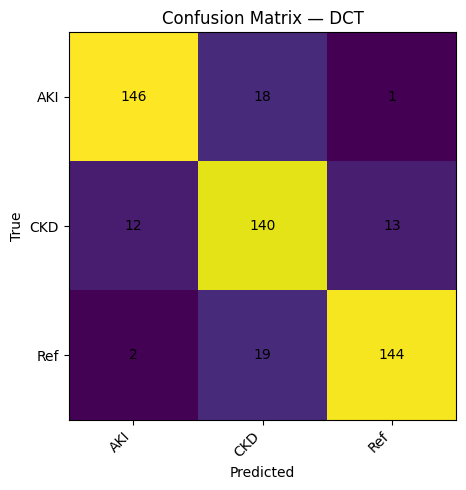

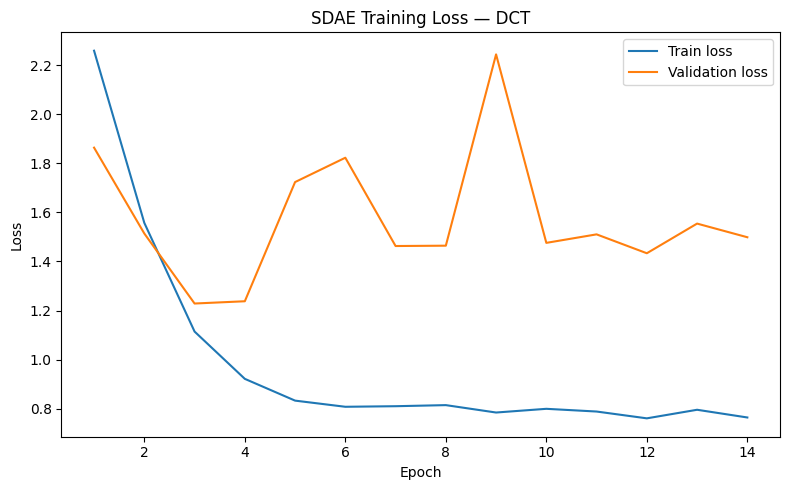

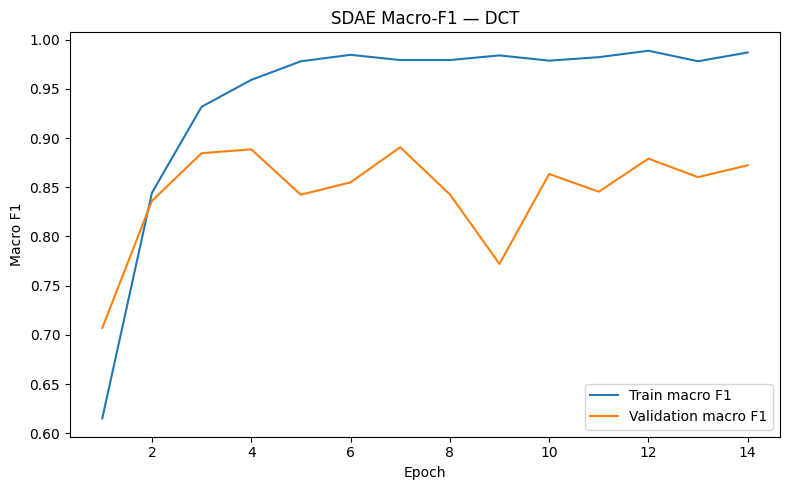

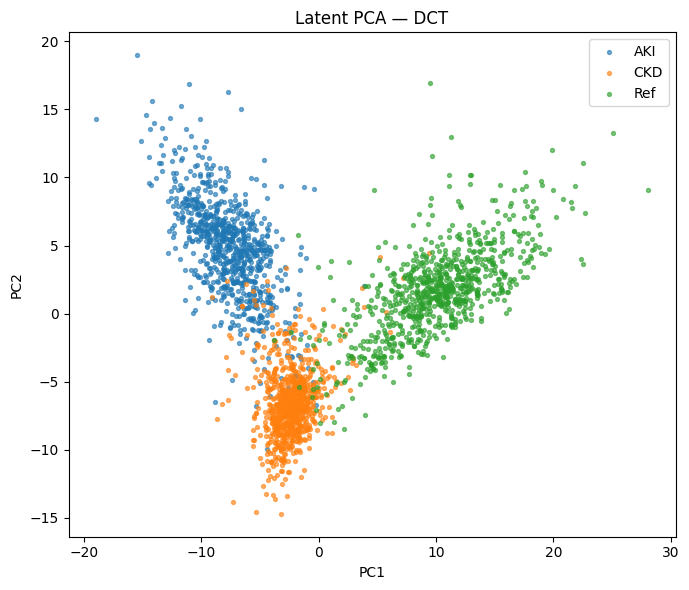

Top 10 biomarkers per class for DCT


,cell_type,gene,class,importance,n_cells_used_for_importance,mean_expr_AKI,mean_expr_CKD,mean_expr_Ref,target_minus_others_mean,abs_target_minus_others_mean,combined_score
0,DCT,MT-ND3,AKI,0.064775,400,189.781662,150.709747,473.329895,-122.238159,122.238159,7.917973
1,DCT,SPP1,AKI,0.081661,400,96.592094,29.662405,49.512512,57.004636,57.004636,4.655034
2,DCT,DEFB1,AKI,0.037713,400,73.634705,67.749382,200.728928,-60.604450,60.604450,2.285555
3,DCT,MT-ND2,AKI,0.032642,400,57.121506,45.923218,157.839035,-44.759621,44.759621,1.461047
4,DCT,MT-ND4L,AKI,0.121356,400,22.403568,28.033514,39.643791,-11.435084,11.435084,1.387712
5,DCT,MT-CYB,AKI,0.041537,400,81.541626,50.362713,176.723068,-32.001265,32.001265,1.329251
6,DCT,MT-CO3,AKI,0.029223,400,182.490677,125.150742,328.105011,-44.137199,44.137199,1.289803
7,DCT,IGFBP7,AKI,0.061120,400,38.771568,13.097249,22.881887,20.782000,20.782000,1.270188
8,DCT,FXYD2,AKI,0.061717,400,32.332474,31.163492,72.419640,-19.459092,19.459092,1.200966
9,DCT,MT-CO1,AKI,0.023149,400,305.421661,189.436005,508.371887,-43.482285,43.482285,1.006579


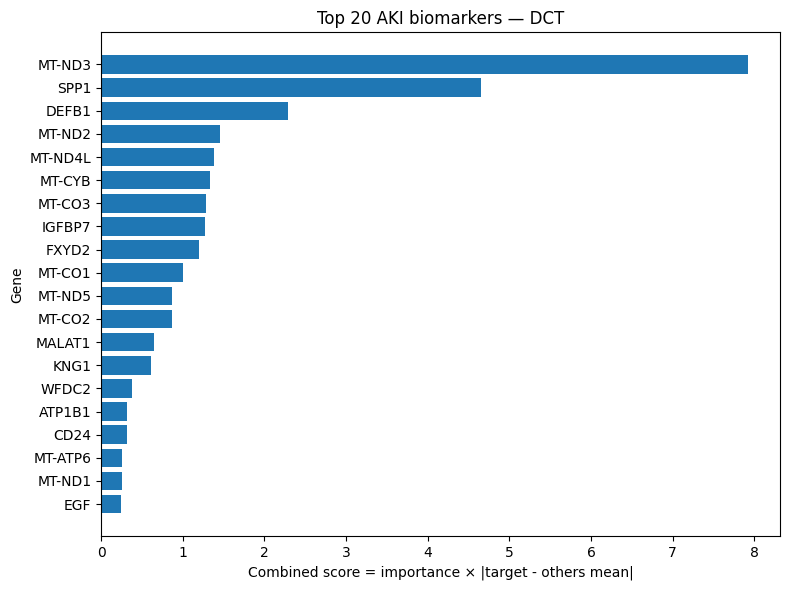

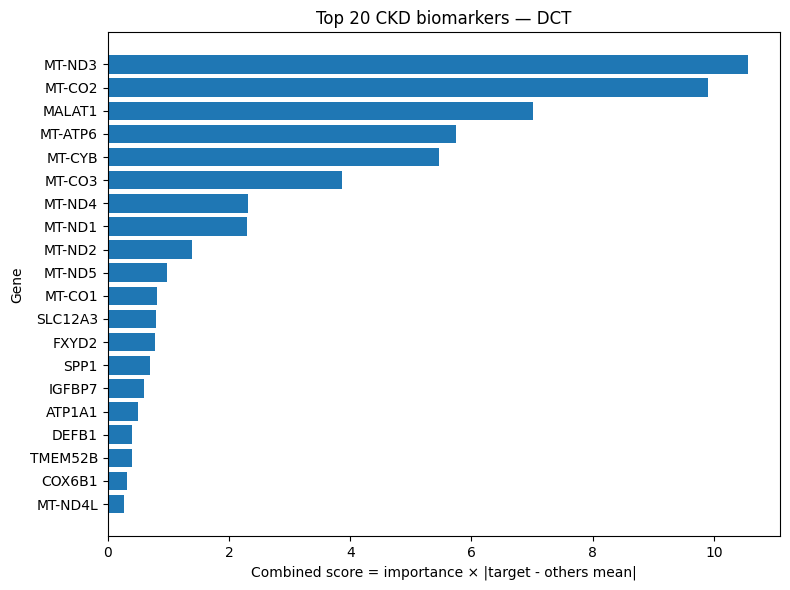

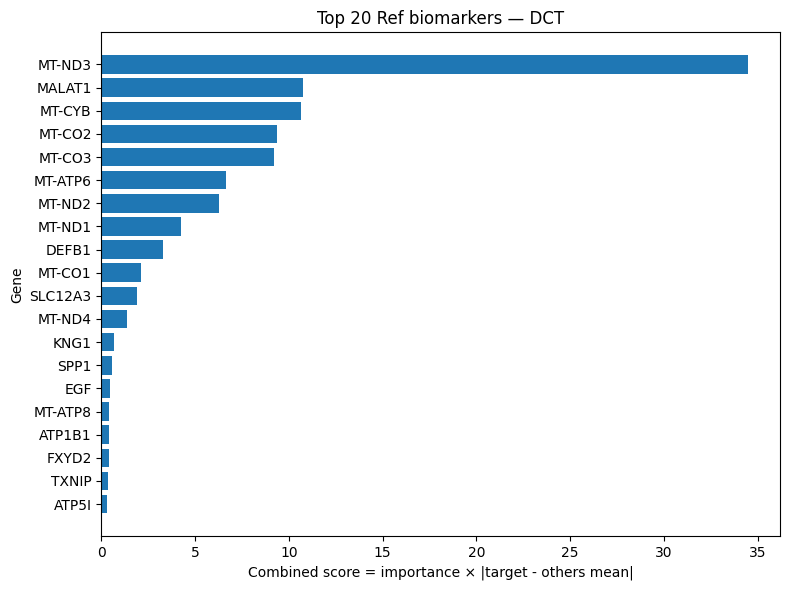

All cell type models completed.


In [21]:
all_metrics = []
all_top_biomarkers = []
all_balance_rows = []

for ct_i, cell_type in enumerate(TARGET_CELL_TYPES, start=1):
    print("" + "=" * 90)
    print(f"[{ct_i}/{len(TARGET_CELL_TYPES)}] Cell type: {cell_type}")
    print("=" * 90)

    ct_safe = make_safe_name(cell_type)
    out_prefix = f"celltype_{ct_safe}"

    # 1) Balanced sampling inside this cell type
    selected_idx, original_counts, sampled_counts, balance_reason = balanced_indices_for_celltype(
        adata, cell_type, seed=SEED + ct_i
    )
    adata_ct = adata[selected_idx].copy()
    adata_ct.obs[CONDITION_COL] = adata_ct.obs[CONDITION_COL].astype(str)

    balance_row = {
        "cell_type": cell_type,
        "original_AKI": original_counts.get("AKI", 0),
        "original_CKD": original_counts.get("CKD", 0),
        "original_Ref": original_counts.get("Ref", 0),
        "sampled_AKI": sampled_counts.get("AKI", 0),
        "sampled_CKD": sampled_counts.get("CKD", 0),
        "sampled_Ref": sampled_counts.get("Ref", 0),
        "balanced_total": int(len(selected_idx)),
        "balance_reason": balance_reason,
    }
    all_balance_rows.append(balance_row)
    print("Original counts:", original_counts)
    print("Sampled counts:", sampled_counts)
    print("Balance reason:", balance_reason)
    print("Balanced adata shape:", adata_ct.shape)

    # 2) HVG 3000 by variance within this balanced cell type
    gene_var = sparse_or_dense_variance(adata_ct.X)
    n_hvg = min(N_TOP_HVG, adata_ct.n_vars)
    top_idx = np.argsort(gene_var)[::-1][:n_hvg]
    adata_hvg = adata_ct[:, top_idx].copy()
    adata_hvg.var["variance"] = gene_var[top_idx]
    adata_hvg.var["variance_rank"] = np.arange(1, adata_hvg.n_vars + 1)

    hvg_df = pd.DataFrame({
        "cell_type": cell_type,
        "gene": adata_hvg.var_names,
        "variance": adata_hvg.var["variance"].values,
        "variance_rank": adata_hvg.var["variance_rank"].values,
    })
    hvg_df.to_csv(TABLE_DIR / f"{out_prefix}__selected_{n_hvg}_hvg_by_variance.csv", index=False)
    print("HVG shape:", adata_hvg.shape)

    # 3) Prepare X/y
    X_raw_log = to_dense_float32(adata_hvg.X)
    labels_str = adata_hvg.obs[CONDITION_COL].astype(str).values

    y_encoder = LabelEncoder()
    y = y_encoder.fit_transform(labels_str).astype(np.int64)
    class_names = list(y_encoder.classes_)
    gene_names = adata_hvg.var_names.to_numpy()

    # Standardize after HVG selection; keeps training stable.
    scaler = StandardScaler(with_mean=True, with_std=True)
    X_trainable = scaler.fit_transform(X_raw_log).astype(np.float32)

    print("Class names:", class_names)
    print("Balanced label counts:")
    display(pd.Series(labels_str).value_counts().rename("count").to_frame())

    # 4) Train/validation/test split
    train_idx, val_idx, test_idx = make_stratified_split(y, seed=SEED)
    split_df = pd.DataFrame({
        "split": ["train"] * len(train_idx) + ["validation"] * len(val_idx) + ["test"] * len(test_idx),
        "condition": np.concatenate([labels_str[train_idx], labels_str[val_idx], labels_str[test_idx]]),
    })
    split_counts = split_df.groupby(["split", "condition"]).size().reset_index(name="n_cells")
    split_counts.to_csv(TABLE_DIR / f"{out_prefix}__train_val_test_condition_counts.csv", index=False)
    print("Split counts:")
    display(split_counts)

    # 5) Train model
    model, history_df, test_metrics, train_idx, val_idx, test_idx, test_loader = train_model_for_celltype(
        X_trainable, y, class_names, out_prefix
    )

    # 6) Test report
    y_test_true, y_test_pred, test_probs = predict_loader(model, test_loader)
    report_text = classification_report(y_test_true, y_test_pred, target_names=class_names, zero_division=0)
    print("Test classification report")
    print(report_text)
    with open(TABLE_DIR / f"{out_prefix}__classification_report.txt", "w") as f:
        f.write(report_text)

    cm = confusion_matrix(y_test_true, y_test_pred, labels=np.arange(len(class_names)))
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_df.to_csv(TABLE_DIR / f"{out_prefix}__confusion_matrix.csv")
    save_confusion_matrix_plot(
        cm_df,
        FIGURE_DIR / f"{out_prefix}__confusion_matrix.png",
        f"Confusion Matrix — {cell_type}",
    )

    metric_row = {
        "cell_type": cell_type,
        "n_cells_balanced": int(X_trainable.shape[0]),
        "n_genes_hvg": int(X_trainable.shape[1]),
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "best_val_macro_f1": float(history_df["val_macro_f1"].max()),
        "epochs_ran": int(history_df["epoch"].max()),
        "balance_reason": balance_reason,
    }
    all_metrics.append(metric_row)

    # 7) Training curves
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"SDAE Training Loss — {cell_type}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{out_prefix}__training_loss_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train macro F1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation macro F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.title(f"SDAE Macro-F1 — {cell_type}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{out_prefix}__training_f1_curve.png", dpi=300)
    plt.show()

    # 8) Latent PCA plot
    model.eval()
    zs = []
    with torch.no_grad():
        for start in range(0, X_trainable.shape[0], 512):
            xb = torch.tensor(X_trainable[start:start+512], dtype=torch.float32).to(DEVICE)
            _, _, z = model(xb, noise_prob=0.0)
            zs.append(z.cpu().numpy())
    Z = np.vstack(zs)
    latent_df = pd.DataFrame(Z, columns=[f"latent_{i+1}" for i in range(Z.shape[1])])
    latent_df["cell_type"] = cell_type
    latent_df["condition"] = labels_str
    latent_df.to_csv(TABLE_DIR / f"{out_prefix}__latent_representation.csv", index=False)

    if Z.shape[0] >= 3:
        pca = PCA(n_components=2, random_state=SEED)
        Z_pca = pca.fit_transform(Z)
        plot_df = pd.DataFrame({"PC1": Z_pca[:, 0], "PC2": Z_pca[:, 1], "condition": labels_str})
        plt.figure(figsize=(7, 6))
        for cls in class_names:
            mask = plot_df["condition"] == cls
            plt.scatter(plot_df.loc[mask, "PC1"], plot_df.loc[mask, "PC2"], s=8, alpha=0.6, label=cls)
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title(f"Latent PCA — {cell_type}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"{out_prefix}__latent_pca_condition.png", dpi=300)
        plt.show()

    # 9) Biomarker identification
    importance_all, top_biomarkers = compute_biomarkers(
        model,
        X_trainable,
        X_raw_log,
        y,
        labels_str,
        gene_names,
        class_names,
        out_prefix,
        cell_type,
    )
    all_top_biomarkers.append(top_biomarkers)

    print("Top 10 biomarkers per class for", cell_type)
    display(top_biomarkers.groupby("class").head(10))

    for cls in class_names:
        df = top_biomarkers[top_biomarkers["class"] == cls].head(20).copy()
        df = df.sort_values("combined_score", ascending=True)
        plt.figure(figsize=(8, 6))
        plt.barh(df["gene"], df["combined_score"])
        plt.xlabel("Combined score = importance × |target - others mean|")
        plt.ylabel("Gene")
        plt.title(f"Top 20 {cls} biomarkers — {cell_type}")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"{out_prefix}__top20_{cls}_biomarkers.png", dpi=300)
        plt.show()

    # Memory clean before next cell type
    del adata_ct, adata_hvg, X_raw_log, X_trainable, y, labels_str, model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print("All cell type models completed.")

## Cell 13 — Combined result tables

সব cell type-এর metrics এবং biomarkers একসাথে save করা হবে।

In [22]:
balance_all_df = pd.DataFrame(all_balance_rows)
balance_all_df.to_csv(TABLE_DIR / "ALL_celltype_balance_used.csv", index=False)
balance_all_df.to_excel(TABLE_DIR / "ALL_celltype_balance_used.xlsx", index=False)

metrics_all_df = pd.DataFrame(all_metrics).sort_values("cell_type")
metrics_all_df.to_csv(TABLE_DIR / "ALL_celltype_sdae_test_metrics.csv", index=False)
metrics_all_df.to_excel(TABLE_DIR / "ALL_celltype_sdae_test_metrics.xlsx", index=False)

biomarkers_all_df = pd.concat(all_top_biomarkers, ignore_index=True)
biomarkers_all_df.to_csv(TABLE_DIR / "ALL_celltype_top_biomarkers_per_class.csv", index=False)
biomarkers_all_df.to_excel(TABLE_DIR / "ALL_celltype_top_biomarkers_per_class.xlsx", index=False)

print("Balance summary:")
display(balance_all_df)
print("Metrics summary:")
display(metrics_all_df)
print("Combined biomarker table preview:")
display(biomarkers_all_df.head(30))

Balance summary:


,cell_type,original_AKI,original_CKD,original_Ref,sampled_AKI,sampled_CKD,sampled_Ref,balanced_total,balance_reason
0,PT,8304,11886,5183,5183,5183,5183,15549,Ref count used
1,TAL,8930,11319,3645,3645,3645,3645,10935,Ref count used
2,IMM,8819,6884,1473,1473,1473,1473,4419,Ref count used
3,EC,1915,3905,2730,1915,1915,1915,5745,minimum condition count used
4,IC,1110,5023,2201,1110,1110,1110,3330,minimum condition count used
5,PC,2025,4632,826,826,826,826,2478,Ref count used
6,CNT,1583,2705,2171,1583,1583,1583,4749,minimum condition count used
7,DCT,824,2694,1806,824,824,824,2472,minimum condition count used


Metrics summary:


,cell_type,n_cells_balanced,n_genes_hvg,test_accuracy,test_macro_f1,test_weighted_f1,best_val_macro_f1,epochs_ran,balance_reason
6,CNT,4749,3000,0.924211,0.924557,0.924560,0.921844,14,minimum condition count used
7,DCT,2472,3000,0.868687,0.869605,0.869605,0.890638,14,minimum condition count used
3,EC,5745,3000,0.870322,0.869756,0.869756,0.880972,30,minimum condition count used
4,IC,3330,3000,0.893393,0.894758,0.894758,0.922734,17,minimum condition count used
2,IMM,4419,3000,0.832579,0.832715,0.832761,0.835282,12,Ref count used
5,PC,2478,3000,0.905242,0.905195,0.905356,0.891635,10,Ref count used
0,PT,15549,3000,0.936013,0.936055,0.936060,0.939711,19,Ref count used
1,TAL,10935,3000,0.898948,0.900070,0.900070,0.911534,9,Ref count used


Combined biomarker table preview:


,cell_type,gene,class,importance,n_cells_used_for_importance,mean_expr_AKI,mean_expr_CKD,mean_expr_Ref,target_minus_others_mean,abs_target_minus_others_mean,combined_score
0,PT,MT-ND3,AKI,0.151146,400,98.846779,130.309601,221.295074,-76.955559,76.955559,11.631508
1,PT,MT1G,AKI,0.157366,400,57.674652,31.546890,28.643833,27.579290,27.579290,4.340032
2,PT,MT-ND2,AKI,0.152889,400,30.918463,39.163532,67.924690,-22.625648,22.625648,3.459213
3,PT,MT-ND1,AKI,0.176314,400,19.580925,27.004358,46.137325,-16.989917,16.989917,2.995565
4,PT,MT-CYB,AKI,0.135956,400,42.749382,44.782890,80.856453,-20.070290,20.070290,2.728679
5,PT,SPP1,AKI,0.087463,400,24.276987,9.201167,2.294285,18.529261,18.529261,1.620620
6,PT,MT-CO3,AKI,0.046590,400,101.646790,99.778351,166.398315,-31.441544,31.441544,1.464852
7,PT,GSTP1,AKI,0.116115,400,12.235778,4.466715,2.739438,8.632701,8.632701,1.002390
8,PT,MT-CO1,AKI,0.060927,400,170.967880,156.306610,216.849869,-15.610359,15.610359,0.951089
9,PT,MT-CO2,AKI,0.031027,400,127.863144,122.669075,184.697250,-25.820019,25.820019,0.801128


## Cell 14 — Make a compact final biomarker table

এই table report/thesis-এ use করার জন্য compact version:

`cell_type`, `class`, `gene`, `combined_score`, `importance`, `target_minus_others_mean`, mean expressions.

In [23]:
compact_cols = [
    "cell_type", "class", "gene", "combined_score", "importance",
    "target_minus_others_mean", "abs_target_minus_others_mean",
]
mean_cols = [c for c in biomarkers_all_df.columns if c.startswith("mean_expr_")]
compact_cols += mean_cols

compact_biomarkers = biomarkers_all_df[compact_cols].copy()
compact_biomarkers = compact_biomarkers.sort_values(["cell_type", "class", "combined_score"], ascending=[True, True, False])
compact_biomarkers.to_csv(TABLE_DIR / "FINAL_compact_celltype_biomarkers.csv", index=False)
compact_biomarkers.to_excel(TABLE_DIR / "FINAL_compact_celltype_biomarkers.xlsx", index=False)

display(compact_biomarkers.groupby(["cell_type", "class"]).head(5))

,cell_type,class,gene,combined_score,importance,target_minus_others_mean,abs_target_minus_others_mean,mean_expr_AKI,mean_expr_CKD,mean_expr_Ref
3600,CNT,AKI,MT-ND3,6.881466,0.064779,-106.229385,106.229385,155.069000,143.684448,378.912323
3601,CNT,AKI,SPP1,4.556365,0.097898,46.541729,46.541729,50.981129,6.851760,2.027039
3602,CNT,AKI,WFDC2,3.190583,0.068767,46.396880,46.396880,58.799313,13.060884,11.743981
3603,CNT,AKI,MT-CO3,2.753204,0.047330,-58.170864,58.170864,127.729607,117.221931,254.579010
3604,CNT,AKI,MT-CO2,2.220388,0.025950,-85.562973,85.562973,206.341171,157.934662,425.873627
...,...,...,...,...,...,...,...,...,...,...
1000,TAL,Ref,MT-ND3,37.556299,0.131639,285.298203,285.298203,149.014221,200.602997,460.106812
1001,TAL,Ref,MALAT1,12.841684,0.072056,178.217045,178.217045,105.561317,145.845047,303.920227
1002,TAL,Ref,MT-CYB,11.310490,0.099041,114.200169,114.200169,48.481354,71.383659,174.132675
1003,TAL,Ref,MT-CO2,10.983257,0.048085,228.414207,228.414207,148.853836,169.265259,387.473755


## Cell 15 — Save README summary

Run শেষ হলে important outputs কোথায় save হয়েছে তার summary তৈরি করা হবে।

In [24]:
summary = f"""# Cell type-wise SDAE Biomarker Discovery Summary

Dataset: {DATA_FILE}
Original shape: {adata.shape}
Condition column: {CONDITION_COL}
Cell type column: {CELLTYPE_COL}
Target classes: {TARGET_CLASSES}
Target cell types: {TARGET_CELL_TYPES}
HVG per cell type: {N_TOP_HVG}
Model: Supervised Denoising Autoencoder
Hidden dims: {HIDDEN_DIMS}
Latent dim: {LATENT_DIM}
Noise probability: {NOISE_PROB}
Balance rule: Ref count if possible; otherwise smallest condition count without replacement.

Important output files:
- {TABLE_DIR / 'selected_celltype_condition_balance_summary.csv'}
- {TABLE_DIR / 'ALL_celltype_balance_used.xlsx'}
- {TABLE_DIR / 'ALL_celltype_sdae_test_metrics.xlsx'}
- {TABLE_DIR / 'ALL_celltype_top_biomarkers_per_class.xlsx'}
- {TABLE_DIR / 'FINAL_compact_celltype_biomarkers.xlsx'}
- Per-cell-type HVG, classification report, confusion matrix, latent PCA, model files are saved with prefix `celltype_<CELLTYPE>__...`
"""

with open(OUTPUT_DIR / "README_summary.md", "w") as f:
    f.write(summary)

print(summary)

# Cell type-wise SDAE Biomarker Discovery Summary

Dataset: /home/nazmul/Research/Celltype SDAE/data/GSE183276_scCv3_with_metadata.h5ad
Original shape: (109741, 37080)
Condition column: condition.l1
Cell type column: subclass.l1
Target classes: ['AKI', 'CKD', 'Ref']
Target cell types: ['PT', 'TAL', 'IMM', 'EC', 'IC', 'PC', 'CNT', 'DCT']
HVG per cell type: 3000
Model: Supervised Denoising Autoencoder
Hidden dims: (512, 128)
Latent dim: 32
Noise probability: 0.2
Balance rule: Ref count if possible; otherwise smallest condition count without replacement.

Important output files:
- /home/nazmul/Research/Celltype SDAE/results_celltype_sdae_3000hvg_biomarkers/tables/selected_celltype_condition_balance_summary.csv
- /home/nazmul/Research/Celltype SDAE/results_celltype_sdae_3000hvg_biomarkers/tables/ALL_celltype_balance_used.xlsx
- /home/nazmul/Research/Celltype SDAE/results_celltype_sdae_3000hvg_biomarkers/tables/ALL_celltype_sdae_test_metrics.xlsx
- /home/nazmul/Research/Celltype SDAE/result

## Cell 16 — How to interpret biomarker table

Biomarker table-এর main columns:

- `cell_type`: কোন kidney cell type থেকে biomarker এসেছে।
- `class`: gene কোন condition-এর জন্য important: `AKI`, `CKD`, অথবা `Ref`।
- `gene`: candidate biomarker gene।
- `importance`: SDAE classifier অনুযায়ী gene-এর Gradient × Input importance।
- `mean_expr_AKI`, `mean_expr_CKD`, `mean_expr_Ref`: balanced cell type data-এর log-normalized average expression।
- `target_minus_others_mean`: target condition-এর expression minus অন্য দুই condition-এর average expression।
  - positive হলে target condition-এ gene বেশি expressed।
  - negative হলে target condition-এ gene কম expressed।
- `combined_score`: model importance এবং expression difference একসাথে ধরে final ranking।

**Report writing idea:**  
প্রতি cell type-এর AKI/CKD/Ref top 10 genes নিয়ে biological validation করো। এরপর literature support, pathway enrichment, এবং known kidney marker cross-check করলে thesis result শক্ত হবে।